In [1]:
import warnings
import logging

# 1. Tắt toàn bộ các cảnh báo chung của Python (FutureWarning, DeprecationWarning, v.v.)
warnings.filterwarnings('ignore')

# 2. Tắt riêng các cảnh báo lải nhải của Matplotlib (ví dụ: lỗi thiếu font)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/dungz878/datathon2026/"

customers_path = os.path.join(base_path, "customers.csv")
geography_path = os.path.join(base_path, "geography.csv")
inventory_path = os.path.join(base_path, "inventory.csv")
order_items_path = os.path.join(base_path, "order_items.csv")
orders_path = os.path.join(base_path, "orders.csv")
payments_path = os.path.join(base_path, "payments.csv")
products_path = os.path.join(base_path, "products.csv")
promotions_path = os.path.join(base_path, "promotions.csv")
returns_path = os.path.join(base_path, "returns.csv")
reviews_path = os.path.join(base_path, "reviews.csv")
sales_path = os.path.join(base_path, "sales.csv")
sample_submission_path = os.path.join(base_path, "sample_submission.csv")
shipments_path = os.path.join(base_path, "shipments.csv")
web_traffic_path = os.path.join(base_path, "web_traffic.csv")

In [4]:
import pandas as pd

# Load datasets
df_customers = pd.read_csv(customers_path)
df_geography = pd.read_csv(geography_path)
df_inventory = pd.read_csv(inventory_path)

# Added low_memory=False to address the DtypeWarning on Column 6
df_order_items = pd.read_csv(order_items_path, low_memory=False)

df_orders = pd.read_csv(orders_path)
df_payments = pd.read_csv(payments_path)
df_products = pd.read_csv(products_path)
df_promotions = pd.read_csv(promotions_path)
df_returns = pd.read_csv(returns_path)
df_reviews = pd.read_csv(reviews_path)
df_sales = pd.read_csv(sales_path)
df_sample_submission = pd.read_csv(sample_submission_path)
df_shipments = pd.read_csv(shipments_path)
df_web_traffic = pd.read_csv(web_traffic_path)

# Quick inspection (recommended)
# print(df_order_items.iloc[:, 6].value_counts()) # Check the contents of Column 6

## **Mô tả Chỉ số Tài chính: Biểu đồ Xu hướng Dài hạn (MA 12M)**

**1. Ý nghĩa Business**
Biểu đồ sử dụng phương pháp **Trung bình động 12 tháng (12-Month Moving Average)** để triệt tiêu các yếu tố biến động mùa vụ (ví dụ: doanh số tăng ảo vào tháng Tết hoặc giảm sâu vào mùa thấp điểm).

**2. Thành phần các Trục**
*   **Trục Hoành (Nằm ngang):** Dòng thời gian tính theo tháng.
*   **Trục Tung (Thẳng đứng):** Giá trị tiền tệ tính bằng VNĐ (Rút gọn theo đơn vị Triệu ).

**3. Định nghĩa các Biến số & Cách tính**
Biểu đồ bóc tách dòng tiền theo 3 lớp chỉ số thuần (Net Metrics) để phản ánh đúng lợi nhuận thực tế thu về túi:

*   **Doanh thu Thuần (Net Revenue - Đường Navy):** Là dòng tiền thực tế doanh nghiệp nhận được.
    *   *Cách tính:* = (Doanh thu niêm yết) - (Tiền giảm giá/Promo) - (Tiền hoàn trả cho khách).
*   **Chi phí Hoạt động (Total COGS - Đường Đỏ):** Giá vốn của lượng hàng đã bán thành công.
    *   *Cách tính:* = (Số lượng hàng khách giữ lại) × (Giá vốn đơn vị).
*   **Lợi nhuận Gộp (Gross Profit - Đường Xanh nhạt):** Mức lãi thu được để trang trải các chi phí quản lý và marketing khác.
    *   *Cách tính:* = (Doanh thu Thuần) - (Chi phí Hoạt động).

In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. TÍNH TOÁN DATA CHUẨN TÀI CHÍNH (NET METRICS)
# =========================================================
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
# Lưu ý: Ép về định dạng datetime ngay từ đầu để dễ vẽ Grid theo năm
df_valid['Month'] = df_valid['order_date'].dt.to_period('M').dt.to_timestamp()

# Gom nhóm trả hàng
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# Merge data
df_items = pd.merge(df_order_items, df_products[['product_id', 'price', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

# Áp dụng công thức tài chính
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity']
df_items['Gross_Revenue'] = df_items['quantity'] * df_items['price']
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs']
df_items['Gross_Profit'] = df_items['Net_Revenue'] - df_items['Total_COGS']

# Tổng hợp theo Tháng
df_master = pd.merge(df_items, df_valid[['order_id', 'Month']], on='order_id', how='inner')
monthly_trend = df_master.groupby('Month').agg(
    Revenue=('Net_Revenue', 'sum'),
    Cost=('Total_COGS', 'sum'),
    Profit=('Gross_Profit', 'sum')
).reset_index()

monthly_trend = monthly_trend.sort_values('Month')

# =========================================================
# 2. TÍNH TOÁN TRUNG BÌNH ĐỘNG (MA 12 THÁNG)
# =========================================================
monthly_trend['MA12_Revenue'] = monthly_trend['Revenue'].rolling(window=12, min_periods=1).mean() / 1e6
monthly_trend['MA12_Cost'] = monthly_trend['Cost'].rolling(window=12, min_periods=1).mean() / 1e6
monthly_trend['MA12_Profit'] = monthly_trend['Profit'].rolling(window=12, min_periods=1).mean() / 1e6

# =========================================================
# 3. THIẾT LẬP KHOẢNG TRỐNG (PADDING) CHO TRỤC X
# =========================================================
# Chừa ra 4 tháng ở đầu và cuối để tạo "không gian thở"
x_start = monthly_trend['Month'].min() - pd.DateOffset(months=4)
x_end = monthly_trend['Month'].max() + pd.DateOffset(months=4)
# Lấy mốc năm nhỏ nhất để gióng lưới chính xác
min_year = monthly_trend['Month'].dt.year.min()

# =========================================================
# 4. VẼ BIỂU ĐỒ VỚI PLOTLY (CORPORATE STYLE + GRID UPDATE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = go.Figure()

# Đường 1: Doanh thu
fig.add_trace(go.Scatter(
    x=monthly_trend['Month'], y=monthly_trend['MA12_Revenue'],
    mode='lines', name='MA 12M - Doanh Thu Thuần',
    line=dict(color='#1A2E46', width=3),
    hovertemplate="Thời gian: %{x|%m/%Y}<br>Doanh Thu: %{y:.2f}B<extra></extra>"
))

# Đường 2: Chi phí
fig.add_trace(go.Scatter(
    x=monthly_trend['Month'], y=monthly_trend['MA12_Cost'],
    mode='lines', name='MA 12M - Chi Phí Hàng Bán (COGS)',
    line=dict(color='#C0392B', width=3),
    hovertemplate="Thời gian: %{x|%m/%Y}<br>Chi Phí: %{y:.2f}B<extra></extra>"
))

# Đường 3: Lợi nhuận
fig.add_trace(go.Scatter(
    x=monthly_trend['Month'], y=monthly_trend['MA12_Profit'],
    mode='lines', name='MA 12M - Lợi Nhuận Gộp',
    line=dict(color='#4A98D3', width=3),
    hovertemplate="Thời gian: %{x|%m/%Y}<br>Lợi Nhuận: %{y:.2f}B<extra></extra>"
))

# =========================================================
# 5. TINH CHỈNH LAYOUT, GRID & LEGEND
# =========================================================
fig.update_layout(
    title={
        'text': "<b>XU HƯỚNG DÀI HẠN: DOANH THU, CHI PHÍ & LỢI NHUẬN</b><br><span style='font-size:14px; color:gray'>Đường Trung Bình Động 12 Tháng (12M Moving Average)</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 20, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA',
    paper_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    
    # DI CHUYỂN LEGEND XUỐNG DƯỚI ĐÁY, DÀN NGANG
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.15, # Đẩy xuống dưới trục X
        xanchor="center", x=0.5, # Căn giữa
        font=dict(size=12),
        bgcolor='rgba(0,0,0,0)' # Trong suốt
    ),
    
    # Nới lỏng lề dưới (margin bottom) để chừa chỗ cho Legend
    margin=dict(t=120, b=100, l=60, r=40),
    width=1100, height=650,
    hovermode="x unified"
)

# Cấu hình Trục Y (Giữ lưới ngang)
fig.update_yaxes(
    title_text="Giá trị tiền tệ (Tỷ VNĐ)",
    title_font=dict(size=13, color='#1A2E46'),
    tickformat=".2f", ticksuffix="M",
    gridcolor='#DDE2E8', zerolinecolor='#BDC3C7', zerolinewidth=1
)

# CẤU HÌNH TRỤC X (PADDING VÀ GRID THEO NĂM)
fig.update_xaxes(
    range=[x_start, x_end], # Chừa khoảng trống 2 đầu
    showgrid=True,          # Bật lưới dọc
    gridcolor='#DDE2E8',
    gridwidth=1.5,
    griddash='dot',         # Dùng nét đứt (dot) cho tinh tế, không bị cứng
    dtick="M12",            # Khoảng cách chia lưới là 12 tháng (1 năm)
    tick0=f"{min_year}-01-01", # Neo vạch lưới chính xác vào ngày 1/1 của năm đầu tiên
    tickformat="%Y",        # Hiển thị text là Năm (VD: 2024)
    tickfont=dict(size=13, color='#1A2E46')
)

# Giữ nguyên Annotation chỉ vào điểm cuối
last_month = monthly_trend['Month'].iloc[-1]
last_profit = monthly_trend['MA12_Profit'].iloc[-1]


fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Phân tích Cấu trúc Doanh thu & Biên Lợi nhuận (Tách lớp Không gian)**

**1. Mục tiêu Chiến lược**
Biểu đồ được thiết kế để cung cấp cái nhìn đồng thời về **Quy mô dòng tiền (Volume)** và **Hiệu quả sinh lời (Efficiency)**. 

**2. Cấu trúc các Trục & Kỹ thuật Ép tầng**
*   **Trục Tung Trái (Y1 - Giá trị):** Hiển thị các thành phần doanh thu (M). 
*   **Trục Tung Phải (Y2 - Phần trăm):** Hiển thị Biên lợi nhuận gộp (%).
*   **Trục Hoành (X):** Dòng thời gian với lưới dọc nét đứt gióng theo từng năm tài chính.

**3. Thành phần Cột Chồng (Stacked Bars - Gross Revenue)**
Tổng chiều cao mỗi cột đại diện cho **Doanh thu lý thuyết (Gross Revenue)**, được bóc tách thành 3 lớp từ dưới lên trên:
*   **Doanh thu Thuần (Net Revenue - Navy):** Dòng tiền thực tế còn lại sau khi trừ mọi khoản giảm trừ.
*   **Tiền Hoàn trả (Refund - Đỏ):** Giá trị đơn hàng bị trả lại, phản ánh chất lượng vận hành/sản phẩm.
*   **Khuyến mãi (Discount/Promo - Cam):** Chi phí chiết khấu để kích cầu, phản ánh mức độ "cắt máu" doanh thu.

**4. Chỉ số Hiệu quả (Line Chart - Gross Margin %)**
*   **Biên Lợi nhuận Gộp** 


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================================
# 1. TÍNH TOÁN DATA CHUẨN TÀI CHÍNH BÓC TÁCH (GROSS TO NET)
# =========================================================
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
df_valid['Month'] = df_valid['order_date'].dt.to_period('M').dt.to_timestamp()

df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

df_items = pd.merge(df_order_items, df_products[['product_id', 'price', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

df_items['Gross_Revenue'] = df_items['quantity'] * df_items['price']
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity']
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs']
df_items['Gross_Profit'] = df_items['Net_Revenue'] - df_items['Total_COGS']

df_master = pd.merge(df_items, df_valid[['order_id', 'Month']], on='order_id', how='inner')
monthly_trend = df_master.groupby('Month').agg(
    Gross_Revenue=('Gross_Revenue', 'sum'),
    Net_Revenue=('Net_Revenue', 'sum'),
    Total_Refund=('refund_amount', 'sum'),
    Total_Discount=('discount_amount', 'sum'),
    Gross_Profit=('Gross_Profit', 'sum')
).reset_index()

monthly_trend['Gross_Margin_Pct'] = (monthly_trend['Gross_Profit'] / monthly_trend['Net_Revenue']) * 100
monthly_trend = monthly_trend.sort_values('Month')

for col in ['Gross_Revenue', 'Net_Revenue', 'Total_Refund', 'Total_Discount']:
    monthly_trend[col] = monthly_trend[col] / 1e6

# =========================================================
# 2. TÍNH TOÁN KHOẢNG TRỐNG (PADDING & AXIS MANIPULATION)
# =========================================================
x_start = monthly_trend['Month'].min() - pd.DateOffset(months=2)
x_end = monthly_trend['Month'].max() + pd.DateOffset(months=2)
min_year = monthly_trend['Month'].dt.year.min()

max_rev = monthly_trend['Gross_Revenue'].max()
max_margin = monthly_trend['Gross_Margin_Pct'].max()

# THỦ THUẬT ÉP TRỤC TẠO 2 TẦNG KHÔNG GIAN
# Y1 (Trái): Thêm 40% giá trị âm để đẩy cột dâng lên cao
y1_min = -max_rev * 0.4
y1_max = max_rev * 1.15

# Y2 (Phải): Nâng trần lên 3.5 lần để đè Line rớt xuống khoảng âm của Y1
y2_min = 0
y2_max = max_margin * 3.5

# =========================================================
# 3. VẼ BIỂU ĐỒ
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(
    x=monthly_trend['Month'], y=monthly_trend['Net_Revenue'],
    name='Doanh thu Thuần (Net Revenue)', marker_color='#4E6C50',
    hovertemplate="Tháng: %{x|%m/%Y}<br>Thuần: %{y:,.0f}M<extra></extra>"
), secondary_y=False)

fig.add_trace(go.Bar(
    x=monthly_trend['Month'], y=monthly_trend['Total_Refund'],
    name='Tiền Hoàn Trả (Refund)', marker_color='#C0392B',
    hovertemplate="Tháng: %{x|%m/%Y}<br>Hoàn trả: %{y:,.0f}M<extra></extra>"
), secondary_y=False)

fig.add_trace(go.Bar(
    x=monthly_trend['Month'], y=monthly_trend['Total_Discount'],
    name='Khuyến Mãi (Discount/Promo)', marker_color='#E67E22',
    customdata=monthly_trend['Gross_Revenue'],
    hovertemplate="Tháng: %{x|%m/%Y}<br>Khuyến mãi: %{y:,.0f}M<br><b>Tổng Gross Rev: %{customdata:,.0f}M</b><extra></extra>"
), secondary_y=False)

# Đường Line: Thu nhỏ size, đổi sang màu Vàng Gold dịu (#F39C12)
fig.add_trace(go.Scatter(
    x=monthly_trend['Month'], y=monthly_trend['Gross_Margin_Pct'],
    name='Biên Lợi Nhuận Gộp (%)',
    mode='lines+markers',
    marker=dict(color='#00ADB5', size=5, line=dict(color='white', width=1)), # Giảm marker
    line=dict(color='#00ADB5', width=3), # Giảm độ dày line
    hovertemplate="Tháng: %{x|%m/%Y}<br>Margin: %{y:.1f}%<extra></extra>"
), secondary_y=True)

# =========================================================
# 4. TINH CHỈNH LAYOUT & ÉP TRỤC
# =========================================================
fig.update_layout(
    title={
        'text': "<b>PHÂN TÍCH CẤU TRÚC DOANH THU & BIÊN LỢI NHUẬN</b><br><span style='font-size:14px; color:gray'>Tổng chiều cao cột đại diện cho Doanh thu lý thuyết (Gross Revenue)</span>",
        'y': 0.96, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    barmode='stack',
    bargap=0.1, # GIẢM KHOẢNG CÁCH, TĂNG ĐỘ DÀY CỘT (Càng nhỏ cột càng mập)
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    
    legend=dict(
        orientation="h", yanchor="top", y=-0.1, xanchor="center", x=0.5,
        font=dict(size=12), bgcolor='rgba(0,0,0,0)'
    ),
    margin=dict(t=120, b=80, l=60, r=60),
    width=1400, height=750, # GIÃN FIGURE TO RA
    hovermode="x unified"
)

# THIẾT LẬP TRỤC Y1 & Y2 DỰA TRÊN KHOẢNG ĐÃ TÍNH
fig.update_yaxes(
    title_text="Giá trị (Triệu VNĐ)", title_font=dict(size=13, color='#1A2E46'),
    tickformat=",.0f", ticksuffix="M", gridcolor='#DDE2E8', zerolinecolor='#BDC3C7',
    range=[y1_min, y1_max], # Ép trục Y trái
    secondary_y=False
)

fig.update_yaxes(
    title_text="Biên lợi nhuận gộp (%)", title_font=dict(size=13, color='#00ADB5'),
    tickformat=".0f", ticksuffix="%", showgrid=False, zerolinecolor='#BDC3C7',
    range=[y2_min, y2_max], # Ép trục Y phải
    secondary_y=True
)

fig.update_xaxes(
    range=[x_start, x_end],
    showgrid=True, gridcolor='#DDE2E8', gridwidth=1.5, griddash='dot',
    dtick="M12", tick0=f"{min_year}-01-01", tickformat="%Y",
    tickfont=dict(size=13, color='#1A2E46')
)

fig.show()

### **Mô tả Chỉ số: Phân tích Tỷ trọng Chi phí trên Doanh thu Thuần (% of Net Revenue)**

**1. Mục tiêu Phân tích**
Biểu đồ này được sử dụng để bóc tách cấu trúc giá vốn và chi phí vận hành (OPEX) nhằm xác định các yếu tố chính ảnh hưởng đến biên lợi nhuận.

**2. Cấu trúc Biểu đồ (100% Stacked Bar)**
*   **Trục Hoành (X):** Chu kỳ thời gian theo tháng.
*   **Trục Tung (Y):** Tỷ lệ phần trăm (%) so với Doanh thu thuần (Net Revenue). 
*   **Đường Baseline (Red Dash):** Ngưỡng 100% đại diện cho điểm hòa vốn lý thuyết của Doanh thu thuần. Các cột vượt ngưỡng này cho thấy tháng đó doanh nghiệp đang chịu lỗ gộp hoặc có chi phí giảm trừ quá cao.

**3. Các thành phần Chi phí (Cost Components)**
Dữ liệu được bóc tách từ các bảng giao dịch (`order_items`, `products`, `shipments`) và tính toán dựa trên các biến số thực:
*   **Khuyến mãi (Promo % - Đỏ):** Tỷ trọng chiết khấu đã áp dụng. Đây là lớp dưới cùng để thấy mức độ "cắt máu" doanh thu trước khi tính các chi phí khác.
*   **Giá vốn (COGS % - Xám):** Thành phần chiếm tỷ trọng lớn nhất, phản ánh giá trị hàng hóa thực tế đã bán thành công (đã loại trừ hàng hoàn).
*   **Phí Vận chuyển (Shipping % - Xanh):** Đại diện cho một phần của chi phí vận hành (OPEX). 


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. TÍNH TOÁN DATA: BÓC TÁCH TỶ TRỌNG CHI PHÍ / NET REVENUE
# =========================================================
# Lọc đơn hàng hợp lệ & chuẩn hóa thời gian
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
df_valid['Month'] = df_valid['order_date'].dt.to_period('M').dt.to_timestamp()

# ---------------------------------------------------------
# BÍ QUYẾT FIX LỖI 0%: CHUẨN HÓA DATA TYPE TRƯỚC KHI MERGE
# ---------------------------------------------------------
# 1. Ép tất cả order_id về dạng chữ (string) để chống trượt Merge
df_valid['order_id'] = df_valid['order_id'].astype(str)
df_shipments['order_id'] = df_shipments['order_id'].astype(str)
df_order_items['order_id'] = df_order_items['order_id'].astype(str)
df_returns['order_id'] = df_returns['order_id'].astype(str)

# 2. Xử lý shipping_fee đề phòng bị dính dấu phẩy/chữ (VD: "30,000")
if df_shipments['shipping_fee'].dtype == 'object':
    df_shipments['shipping_fee'] = df_shipments['shipping_fee'].str.replace(',', '', regex=False)
df_shipments['shipping_fee'] = pd.to_numeric(df_shipments['shipping_fee'], errors='coerce').fillna(0)
# ---------------------------------------------------------

# Tính Refund
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# Merge items, products, returns
df_items = pd.merge(df_order_items, df_products[['product_id', 'price', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

# Tính Net Revenue & COGS tại mức độ Line Item
df_items['Gross_Revenue'] = df_items['quantity'] * df_items['price']
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity']
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs']

# Gom nhóm theo đơn hàng
order_level = df_items.groupby('order_id').agg(
    Net_Revenue=('Net_Revenue', 'sum'),
    Total_COGS=('Total_COGS', 'sum'),
    Total_Discount=('discount_amount', 'sum')
).reset_index()

# LẤY PHÍ SHIP TỪ BẢNG SHIPMENTS
df_order_ship = pd.merge(order_level, df_shipments[['order_id', 'shipping_fee']], on='order_id', how='left')
df_order_ship['shipping_fee'] = df_order_ship['shipping_fee'].fillna(0) 

# Merge với df_valid để lấy mốc thời gian theo tháng
df_master = pd.merge(df_order_ship, df_valid[['order_id', 'Month']], on='order_id', how='inner')

# Gộp dữ liệu theo Tháng
monthly_pct = df_master.groupby('Month').agg(
    Net_Revenue=('Net_Revenue', 'sum'),
    Total_COGS=('Total_COGS', 'sum'),
    Total_Discount=('Total_Discount', 'sum'),
    Total_Shipping=('shipping_fee', 'sum')
).reset_index()

# TÍNH % TRÊN TỔNG NET REVENUE
monthly_pct['COGS_Pct'] = (monthly_pct['Total_COGS'] / monthly_pct['Net_Revenue']) * 100
monthly_pct['Promo_Pct'] = (monthly_pct['Total_Discount'] / monthly_pct['Net_Revenue']) * 100
monthly_pct['Shipping_Pct'] = (monthly_pct['Total_Shipping'] / monthly_pct['Net_Revenue']) * 100

monthly_pct = monthly_pct.sort_values('Month')
# =========================================================
# 2. VẼ BIỂU ĐỒ (STACKED BAR CHỨNG MINH OPEX NHỎ)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"
fig = go.Figure()

# Lớp 1: Khuyến mãi (Màu Đỏ/Cam Corporate) - Nằm dưới cùng
fig.add_trace(go.Bar(
    x=monthly_pct['Month'], y=monthly_pct['Promo_Pct'],
    name='Khuyến mãi (Promo %)', marker_color='#E74C3C',
    hovertemplate="Tháng: %{x|%m/%Y}<br>Promo: %{y:.1f}%<extra></extra>"
))

# Lớp 2: Giá vốn (Màu Xám) - Chiếm phần lớn
fig.add_trace(go.Bar(
    x=monthly_pct['Month'], y=monthly_pct['COGS_Pct'],
    name='Giá vốn (COGS %)', marker_color='#BDC3C7',
    hovertemplate="Tháng: %{x|%m/%Y}<br>COGS: %{y:.1f}%<extra></extra>"
))

# Lớp 3: Phí Ship / OPEX (Màu Xanh Nhạt) - Lớp mỏng nhất trên đỉnh
fig.add_trace(go.Bar(
    x=monthly_pct['Month'], y=monthly_pct['Shipping_Pct'],
    name='Phí Ship (Shipping % - OPEX)', marker_color='#4A98D3',
    hovertemplate="Tháng: %{x|%m/%Y}<br>Shipping: %{y:.2f}%<extra></extra>"
))

# Thêm đường Đỏ Đứt Nét ngang mức 100% (Đại diện cho Net Revenue)
fig.add_hline(
    y=100, line_dash="dash", line_color="#E74C3C", line_width=2,
    annotation_text="Ngưỡng 100% Net Revenue", 
    annotation_position="top left", annotation_font_color="#E74C3C"
)

# =========================================================
# 3. TINH CHỈNH LAYOUT (CORPORATE STYLE)
# =========================================================
fig.update_layout(
    title={
        'text': "<b>PHÂN TÍCH TỶ TRỌNG CÁC LOẠI CHI PHÍ SO VỚI DOANH THU THUẦN</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    barmode='stack',
    bargap=0.15,
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    
    # Đưa Legend xuống dưới đáy (y = -0.15)
    legend=dict(
        orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5,
        title="<b>Loại chi phí:</b>", font=dict(size=12), bgcolor='rgba(0,0,0,0)'
    ),
    # Nới margin bottom (b=100) để chừa chỗ cho legend không bị cắt chữ
    margin=dict(t=100, b=100, l=60, r=40),
    width=1400, height=500, # Kéo dài bề ngang
    hovermode="x unified"
)

# Cấu hình Trục Y
fig.update_yaxes(
    title_text="% / Net Revenue", title_font=dict(size=13, color='#1A2E46'),
    tickformat=".0f", showgrid=True, gridcolor='#DDE2E8', zerolinecolor='#BDC3C7'
)

# Cấu hình Trục X
min_year = monthly_pct['Month'].dt.year.min()
x_start = monthly_pct['Month'].min() - pd.DateOffset(months=2)
x_end = monthly_pct['Month'].max() + pd.DateOffset(months=2)

fig.update_xaxes(
    range=[x_start, x_end],
    showgrid=True, gridcolor='#DDE2E8', gridwidth=1.5, griddash='dot',
    dtick="M12", tick0=f"{min_year}-01-01", tickformat="%Y",
    tickfont=dict(size=13, color='#1A2E46')
)

fig.show()

### **Mô tả Chỉ số: Phân tích Tương quan Thực trạng (Tồn kho – Khuyến mãi – Lợi nhuận)**

**1. Mục tiêu và Cấu trúc (Visual Layout)**
*   **Panel trên :** Theo dõi mối quan hệ giữa **Số ngày tồn kho bình quân (Days of Supply)** và **Cường độ khuyến mãi (% Promo Intensity)**.
*   **Panel dưới :** Theo dõi biến động của **Biên lợi nhuận gộp (Gross Margin %)**.
*   **Phân nhóm (Cohorts):** Dữ liệu được chia theo Quý (Q1-Q4) và đặc tính năm (Chẵn/Lẻ) hoặc giai đoạn kinh doanh (Trưởng thành/Sau trưởng thành).

**2. Các thành phần và Logic tính toán**
*   **Bình quân tồn kho (Cột Navy):** Được tính toán từ trung bình cộng của chỉ số `days_of_supply` trong bảng Vận hành (`inventory.csv`).
*   **Cường độ khuyến mãi (Đường Cam):** Tỷ lệ phần trăm giữa tổng tiền giảm giá (`discount_amount`) chia cho Doanh thu thuần (`Net_Revenue`)
*   **Biên lợi nhuận gộp (Đường Đỏ Gạch):** Hiệu số giữa Doanh thu thuần và Giá vốn hàng bán (COGS) chia cho Doanh thu thuần.


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================================
# 1. TÍNH TOÁN DATA: DOANH THU & LỢI NHUẬN
# =========================================================
# Lọc đơn hợp lệ & chuẩn hóa thời gian
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
df_valid['Year'] = df_valid['order_date'].dt.year
df_valid['Quarter'] = df_valid['order_date'].dt.quarter
df_valid['year_type'] = np.where(df_valid['Year'] % 2 == 0, 'Năm Chẵn', 'Năm Lẻ')

# Ép kiểu dữ liệu (String) chống trượt khi Merge
df_valid['order_id'] = df_valid['order_id'].astype(str)
df_order_items['order_id'] = df_order_items['order_id'].astype(str)
df_returns['order_id'] = df_returns['order_id'].astype(str)

# Xử lý trả hàng
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# Merge items & returns. Lấy 'cogs' từ products, 'unit_price' từ order_items
df_items = pd.merge(df_order_items, df_products[['product_id', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

# Tính toán các chỉ số ròng (Net)
df_items['Gross_Revenue'] = df_items['quantity'] * df_items['unit_price']
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity']
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs']
df_items['Gross_Profit'] = df_items['Net_Revenue'] - df_items['Total_COGS']

# Gom nhóm theo Đơn hàng
order_level = df_items.groupby('order_id').agg(
    Gross_Revenue=('Gross_Revenue', 'sum'),
    Net_Revenue=('Net_Revenue', 'sum'),
    Total_Discount=('discount_amount', 'sum'),
    Gross_Profit=('Gross_Profit', 'sum')
).reset_index()

# Gắn thời gian vào Đơn hàng
df_sales = pd.merge(order_level, df_valid[['order_id', 'Year', 'Quarter', 'year_type']], on='order_id', how='inner')

# =========================================================
# 2. XỬ LÝ DATA: TỒN KHO
# =========================================================
df_inv = df_inventory.copy()
df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
df_inv['Year'] = df_inv['snapshot_date'].dt.year
df_inv['Quarter'] = df_inv['snapshot_date'].dt.quarter
df_inv['year_type'] = np.where(df_inv['Year'] % 2 == 0, 'Năm Chẵn', 'Năm Lẻ')

# =========================================================
# 3. TẠO COHORTS VÀ GỘP NHÓM
# =========================================================
def get_cohort(row):
    q = row['Quarter']
    yt = row['year_type']
    y = row['Year']
    
    # Mốc năm trưởng thành (Giả định 2018, nhớ đổi nếu cần)
    maturity_threshold = 2018 
    
    if q == 1:
        return f"Q1<br>({yt})"
    elif q == 2:
        phase = "GĐ Trưởng thành" if y <= maturity_threshold else "Sau Trưởng thành"
        return f"Q2<br>({phase})"
    elif q == 3:
        return f"Q3<br>({yt})"
    elif q == 4:
        return "Q4<br>(Cuối năm)"

df_sales['Period'] = df_sales.apply(get_cohort, axis=1)
df_inv['Period'] = df_inv.apply(get_cohort, axis=1)

# Tổng hợp Data Sales theo Period
sales_cohort = df_sales.groupby('Period').agg(
    Gross_Revenue=('Gross_Revenue', 'sum'),
    Net_Revenue=('Net_Revenue', 'sum'),
    Total_Discount=('Total_Discount', 'sum'),
    Gross_Profit=('Gross_Profit', 'sum')
).reset_index()

# Tổng hợp Data Tồn kho (Dùng days_of_supply)
inv_cohort = df_inv.groupby('Period').agg(
    avg_days_of_supply=('days_of_supply', 'mean') 
).reset_index()

# Gộp bảng
df_plot = pd.merge(sales_cohort, inv_cohort, on='Period', how='outer')

# ---------------------------------------------------------
# CẬP NHẬT CÔNG THỨC: CHIA CHO NET_REVENUE
# ---------------------------------------------------------
df_plot['promo_intensity_pct'] = (df_plot['Total_Discount'] / df_plot['Net_Revenue']) * 100
df_plot['gross_margin_pct'] = (df_plot['Gross_Profit'] / df_plot['Net_Revenue']) * 100
# ---------------------------------------------------------

# Khai báo Factor Levels để sắp xếp trục X
ordered_periods = [
    'Q1<br>(Năm Chẵn)', 'Q1<br>(Năm Lẻ)', 
    'Q2<br>(GĐ Trưởng thành)', 'Q2<br>(Sau Trưởng thành)', 
    'Q3<br>(Năm Chẵn)', 'Q3<br>(Năm Lẻ)', 'Q4<br>(Cuối năm)'
]
df_plot['Period'] = pd.Categorical(df_plot['Period'], categories=ordered_periods, ordered=True)
df_plot = df_plot.sort_values('Period')

# =========================================================
# 4. VẼ BIỂU ĐỒ (PLOTLY CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

# Khởi tạo 2 Panels
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.1,
    row_heights=[0.65, 0.35],
    specs=[[{"secondary_y": True}], [{"secondary_y": False}]]
)

# ---- PANEL 1: TỒN KHO & KHUYẾN MÃI ----
# Cột: Bình quân tồn kho 
fig.add_trace(go.Bar(
    x=df_plot['Period'], y=df_plot['avg_days_of_supply'],
    name='Bình quân tồn kho (Ngày)',
    marker_color='#4C72B0', width=0.5, opacity=0.8,
    text=df_plot['avg_days_of_supply'].fillna(0).round(0).astype(int),
    textposition='inside', 
    insidetextanchor='start', # Đẩy số xuống sát đáy cột
    textfont=dict(color='white', size=13, weight='bold') 
), row=1, col=1, secondary_y=False)

# Đường: Cường độ khuyến mãi
fig.add_trace(go.Scatter(
    x=df_plot['Period'], y=df_plot['promo_intensity_pct'],
    name='Cường độ khuyến mãi (%)',
    mode='lines+markers+text',
    marker=dict(color='#E69F00', size=9), line=dict(color='#E69F00', width=3),
    text=df_plot['promo_intensity_pct'].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else ""),
    textposition='top center', textfont=dict(color='#D35400', size=13, weight='bold')
), row=1, col=1, secondary_y=True)


# ---- PANEL 2: BIÊN LỢI NHUẬN GỘP ----
# Tạo mảng vị trí text tùy chỉnh: Q3 (Năm Lẻ) nằm dưới, còn lại nằm trên
custom_text_positions = ['bottom center' if 'Q3<br>(Năm Lẻ)' in str(p) else 'top center' for p in df_plot['Period']]

# Đường: Gross Margin
fig.add_trace(go.Scatter(
    x=df_plot['Period'], y=df_plot['gross_margin_pct'],
    name='Bình quân BLN gộp (%)',
    mode='lines+markers+text',
    marker=dict(color='#D55E00', size=9), line=dict(color='#D55E00', width=3),
    text=df_plot['gross_margin_pct'].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else ""),
    textposition=custom_text_positions, # Dùng mảng vị trí đã tạo ở trên
    textfont=dict(color='#D55E00', size=13, weight='bold')
), row=2, col=1)

# Thêm đường 0
fig.add_hline(y=0, line_dash="solid", line_color="darkred", line_width=1.5, row=2, col=1)

# ---- THÊM CÁC ĐƯỜNG VLINE PHÂN QUÝ ----
for v_pos in [1.5, 3.5, 5.5]:
    fig.add_vline(x=v_pos, line_dash="dash", line_color="gray", line_width=1.5, opacity=0.6)

# ---- TINH CHỈNH CORPORATE LAYOUT ----
fig.update_layout(
    title={
        'text': "<b>TỒN KHO, KHUYẾN MÃI & LỢI NHUẬN GỘP</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA', 
    font=dict(family=vietnamese_font, color='#2C3E50'),
    showlegend=False, 
    margin=dict(t=80, b=60, l=60, r=60),
    width=1300, height=800,
    hovermode="x unified"
)

fig.update_yaxes(title_text="<b>Bình quân tồn kho (Ngày)</b>", title_font=dict(color='#4C72B0'), showgrid=True, gridcolor='#E5E8E8', range=[0, df_plot['avg_days_of_supply'].max() * 1.3], row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="<b>Cường độ khuyến mãi (%)</b>", title_font=dict(color='#E69F00'), tickformat=".0f", ticksuffix="%", showgrid=False, range=[0, df_plot['promo_intensity_pct'].max() * 1.5], row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="<b>Bình quân BLN gộp (%)</b>", title_font=dict(color='#D55E00'), tickformat=".0f", ticksuffix="%", showgrid=True, gridcolor='#E5E8E8', row=2, col=1)

fig.update_xaxes(showgrid=False, tickfont=dict(weight='bold', size=12, color='black'))

y2_min = df_plot['gross_margin_pct'].min()
y2_max = df_plot['gross_margin_pct'].max()

fig.update_yaxes(
    title_text="<b>Bình quân BLN gộp (%)</b>", 
    title_font=dict(color='#D55E00'), 
    tickformat=".0f", ticksuffix="%", 
    showgrid=True, gridcolor='#E5E8E8', 
    range=[y2_min - 5, y2_max + 5], # Mở rộng biên trên dưới thêm 5% để chữ có không gian
    row=2, col=1
)

fig.show()

### **Tỷ lệ Chuyển đổi (Conversion Rate) theo Nguồn Traffic**

**1. Định nghĩa và Công thức**
Chỉ số này phản ánh hiệu quả của từng kênh Marketing trong việc thúc đẩy hành vi mua hàng thực tế từ khách truy cập website.
*   **Công thức:** $CR = (\text{Tổng số đơn hàng thành công} / \text{Tổng số Sessions}) \times 100\%.
*   **Dữ liệu sử dụng:** Kết hợp từ bảng `web_traffic.csv` (Sessions) và bảng `orders.csv` (Orders - loại bỏ trạng thái `cancelled`).

**2. Cấu trúc Trực quan (Visual Layout)**
*   **Đường Dot Plot (Cam):** Thể hiện sự biến động của tỷ lệ chuyển đổi giữa các nguồn..
*   **Cột Số liệu bên phải (Volume):** Hiển thị quy mô truy cập thực tế (Sessions) của từng nguồn để tránh sự sai lệch khi đánh giá các kênh có CR cao nhưng lượng truy cập quá thấp.



In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. TÍNH TOÁN DATA: SESSIONS & ĐƠN HÀNG
# =========================================================
# Xử lý bảng Orders (Lấy đơn hàng hợp lệ)
df_valid_orders = df_orders[df_orders['order_status'] != 'cancelled'].copy()

# Gom nhóm tổng đơn hàng theo Kênh (order_source)
orders_by_source = df_valid_orders.groupby('order_source').size().reset_index(name='Total_Orders')

# Gom nhóm tổng Sessions theo Kênh (traffic_source) từ bảng web_traffic
traffic_by_source = df_web_traffic.groupby('traffic_source').agg(
    Total_Sessions=('sessions', 'sum')
).reset_index()

# Merge 2 bảng với nhau (order_source = traffic_source)
df_cr = pd.merge(traffic_by_source, orders_by_source, left_on='traffic_source', right_on='order_source', how='inner')

# TÍNH TOÁN CONVERSION RATE (%)
df_cr['Conversion_Rate'] = (df_cr['Total_Orders'] / df_cr['Total_Sessions']) * 100

# Sắp xếp từ thấp đến cao để vẽ biểu đồ line chạy từ dưới lên trên
df_cr = df_cr.sort_values('Conversion_Rate', ascending=True).reset_index(drop=True)

# =========================================================
# 2. VẼ BIỂU ĐỒ (PLOTLY CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = go.Figure()

# Thêm đường line và các điểm markers (Dot Plot)
fig.add_trace(go.Scatter(
    x=df_cr['Conversion_Rate'],
    y=df_cr['traffic_source'],
    mode='lines+markers+text',
    name='Conversion Rate',
    marker=dict(color='#E67E22', size=12, line=dict(color='white', width=1.5)), 
    line=dict(color='#E67E22', width=3),
    text=df_cr['Conversion_Rate'].apply(lambda x: f"<b>{x:.3f}%</b>"), 
    textposition='bottom right', # Đổi từ 'middle right' thành 'bottom right'
    textfont=dict(color='#2C3E50', size=13),
    hovertemplate="Nguồn: %{y}<br>Conversion Rate: %{x:.3f}%<br>Đơn hàng: %{customdata[0]:,}<extra></extra>",
    customdata=df_cr[['Total_Orders']]
))

# =========================================================
# 3. THÊM CỘT VOLUME SESSIONS BÊN PHẢI & TINH CHỈNH LAYOUT
# =========================================================
# Thêm Annotation hiển thị Tổng Sessions ở lề phải của mỗi hàng
for index, row in df_cr.iterrows():
    fig.add_annotation(
        x=1.12, # Đẩy sang lề phải ngoài khu vực vẽ đồ thị
        y=row['traffic_source'],
        xref="paper", yref="y",
        text=f"{row['Total_Sessions']:,.0f}", # Format phân cách hàng nghìn
        showarrow=False,
        font=dict(size=13, color='#7F8C8D', family=vietnamese_font),
        xanchor='right',
        yanchor='middle'
    )

# Cấu hình Layout
fig.update_layout(
    title={
        'text': "<b>CONVERSION RATE THEO NGUỒN TRAFFIC</b><br><span style='font-size:14px; color:gray'>Social Media có conversion cao nhất | Organic Search có volume sessions lớn nhất</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA', 
    font=dict(family=vietnamese_font, color='#2C3E50'),
    
    # Nới margin phải (r=150) để có chỗ hiển thị cột Sessions
    margin=dict(t=100, b=80, l=120, r=150),
    width=1100, height=500,
    hovermode="y unified"
)

# Cấu hình Trục X (Grid dọc đứt nét, ẩn line trục)
fig.update_xaxes(
    title_text="Conversion Rate (%)", title_font=dict(weight='bold'),
    tickformat=".3f", ticksuffix="%", 
    showgrid=True, gridcolor='#E5E8E8', griddash='solid',
    zeroline=False, showline=False,
    range=[df_cr['Conversion_Rate'].min() * 0.95, df_cr['Conversion_Rate'].max() * 1.05] # Nới rộng trục X một chút để không bị lẹm chữ
)

# Cấu hình Trục Y (Ẩn grid ngang, hiện tên nguồn)
fig.update_yaxes(
    title_text="Traffic Source", title_font=dict(weight='bold'),
    showgrid=False, zeroline=False,
    tickfont=dict(size=13, color='#34495E')
)

# Ghi chú dưới cùng (Footer)
fig.add_annotation(
    x=1.12, y=-0.18, xref="paper", yref="paper",
    text="Dữ liệu toàn bộ giai đoạn • Đơn vị: % | Sessions",
    showarrow=False, font=dict(size=11, color='#7F8C8D'), xanchor='right'
)

fig.show()

###  **Tỷ trọng Đơn hàng và Đóng góp Doanh thu theo Thiết bị**

**1. Mục tiêu Phân tích**
Xác định nền tảng thiết bị chủ lực mà khách hàng sử dụng để thực hiện giao dịch cuối cùng.

**2. Phương pháp Tính toán**
*   **Tỷ trọng đơn hàng (%):** Phần trăm số lượng đơn hàng của một loại thiết bị trên tổng số đơn hàng hợp lệ toàn hệ thống.
*   **Cột Doanh thu (Net Revenue):** Tổng số tiền thực thu (sau khi trừ giảm giá và hoàn trả) mang lại từ mỗi loại thiết bị.
*   **Nguồn dữ liệu:** Trích xuất từ cột `device_type` trong bảng giao dịch `orders.csv.


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. TÍNH TOÁN DATA: TỶ TRỌNG ĐƠN HÀNG & DOANH THU THEO DEVICE
# =========================================================
# Lọc đơn hợp lệ từ orders
df_valid_orders = df_orders[df_orders['order_status'] != 'cancelled'].copy()

# ÉP KIỂU DỮ LIỆU ĐỂ TRÁNH LỖI MERGE (Thêm 2 dòng này)
df_valid_orders['order_id'] = df_valid_orders['order_id'].astype(str)
order_level['order_id'] = order_level['order_id'].astype(str)

# Giả định bạn đã có bảng order_level chứa Doanh thu thuần (Net_Revenue) của từng đơn hàng từ các bước trước
df_device_rev = pd.merge(df_valid_orders, order_level[['order_id', 'Net_Revenue']], on='order_id', how='inner')
# Gom nhóm theo Thiết bị (device_type)
device_stats = df_device_rev.groupby('device_type').agg(
    Total_Orders=('order_id', 'count'),
    Net_Revenue=('Net_Revenue', 'sum')
).reset_index()

# TÍNH TOÁN TỶ TRỌNG ĐƠN HÀNG (%)
total_valid_orders = device_stats['Total_Orders'].sum()
device_stats['Order_Pct'] = (device_stats['Total_Orders'] / total_valid_orders) * 100

# Sắp xếp từ thấp đến cao để vẽ biểu đồ line từ dưới lên
device_stats = device_stats.sort_values('Order_Pct', ascending=True).reset_index(drop=True)

# =========================================================
# 2. VẼ BIỂU ĐỒ (PLOTLY CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = go.Figure()

# Thêm đường line và các điểm markers (Dot Plot)
fig.add_trace(go.Scatter(
    x=device_stats['Order_Pct'],
    y=device_stats['device_type'],
    mode='lines+markers+text',
    name='Tỷ trọng Đơn hàng',
    marker=dict(color='#27AE60', size=12, line=dict(color='white', width=1.5)), 
    line=dict(color='#27AE60', width=3),
    text=device_stats['Order_Pct'].apply(lambda x: f"<b>{x:.1f}%</b>"), 
    textposition='bottom right', # Đổi từ 'middle right' thành 'bottom right' ở đây
    textfont=dict(color='#2C3E50', size=13),
    hovertemplate="Thiết bị: %{y}<br>Tỷ trọng đơn: %{x:.1f}%<br>Số đơn thực: %{customdata[0]:,}<extra></extra>",
    customdata=device_stats[['Total_Orders']]
))

# =========================================================
# 3. THÊM CỘT TỔNG DOANH THU BÊN PHẢI & TINH CHỈNH LAYOUT
# =========================================================
# Thêm Annotation hiển thị Tổng Doanh Thu ở lề phải
for index, row in device_stats.iterrows():
    fig.add_annotation(
        x=1.12, 
        y=row['device_type'],
        xref="paper", yref="y",
        text=f"${row['Net_Revenue']:,.0f}", # Thêm ký hiệu tiền tệ và phân cách
        showarrow=False,
        font=dict(size=13, color='#7F8C8D', family=vietnamese_font, weight='bold'),
        xanchor='right',
        yanchor='middle'
    )

# Cấu hình Layout
fig.update_layout(
    title={
        'text': "<b>TỶ TRỌNG ĐƠN HÀNG THEO THIẾT BỊ (DEVICE TYPE)</b><br><span style='font-size:14px; color:gray'>Phân bổ số lượng đơn hàng chốt thành công và Tổng doanh thu mang lại</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA', 
    font=dict(family=vietnamese_font, color='#2C3E50'),
    
    # Nới margin phải (r=180) để có không gian chứa cột Doanh thu
    margin=dict(t=100, b=80, l=120, r=180),
    width=1100, height=450,
    hovermode="y unified"
)

# Cấu hình Trục X
fig.update_xaxes(
    title_text="Tỷ trọng Đơn hàng (%)", title_font=dict(weight='bold'),
    tickformat=".0f", ticksuffix="%", 
    showgrid=True, gridcolor='#E5E8E8', griddash='solid',
    zeroline=False, showline=False,
    range=[0, device_stats['Order_Pct'].max() * 1.15] # Nới rộng trục X để text không đâm lề
)

# Cấu hình Trục Y
fig.update_yaxes(
    title_text="Device Type", title_font=dict(weight='bold'),
    showgrid=False, zeroline=False,
    tickfont=dict(size=13, color='#34495E', weight='bold')
)

# Ghi chú dưới cùng (Footer)
fig.add_annotation(
    x=1.12, y=-0.22, xref="paper", yref="paper",
    text="Đơn vị: % Tổng số đơn | Cột phải: Doanh thu thuần (VND/USD)",
    showarrow=False, font=dict(size=11, color='#7F8C8D'), xanchor='right'
)

fig.show()

### **Bản đồ Nhiệt Tỷ lệ Giữ chân Khách hàng (Retention Cohort)**

**1. Mục tiêu Phân tích**
Theo dõi vòng đời mua sắm và tỷ lệ khách hàng tiếp tục quay lại giao dịch qua từng tháng, phân loại dựa trên tháng mà họ thực hiện đơn hàng đầu tiên.

**2. Phương pháp Tính toán**
*   **Nhóm khách hàng (Cohort Month - Trục Y):** Tập hợp các khách hàng có cùng tháng mua hàng đầu tiên.
*   **Khoảng cách tháng (Cohort Index - Trục X):** Số tháng trôi qua tính từ tháng mua hàng đầu tiên. Tính bằng: `(Năm đặt hàng - Năm mua lần đầu) * 12 + (Tháng đặt hàng - Tháng mua lần đầu)`.
*   **Tỷ lệ giữ chân (%):** Số lượng khách hàng định danh (unique customers) có phát sinh đơn hàng ở tháng thứ N chia cho Tổng số lượng khách hàng ban đầu của nhóm đó ở tháng 0.

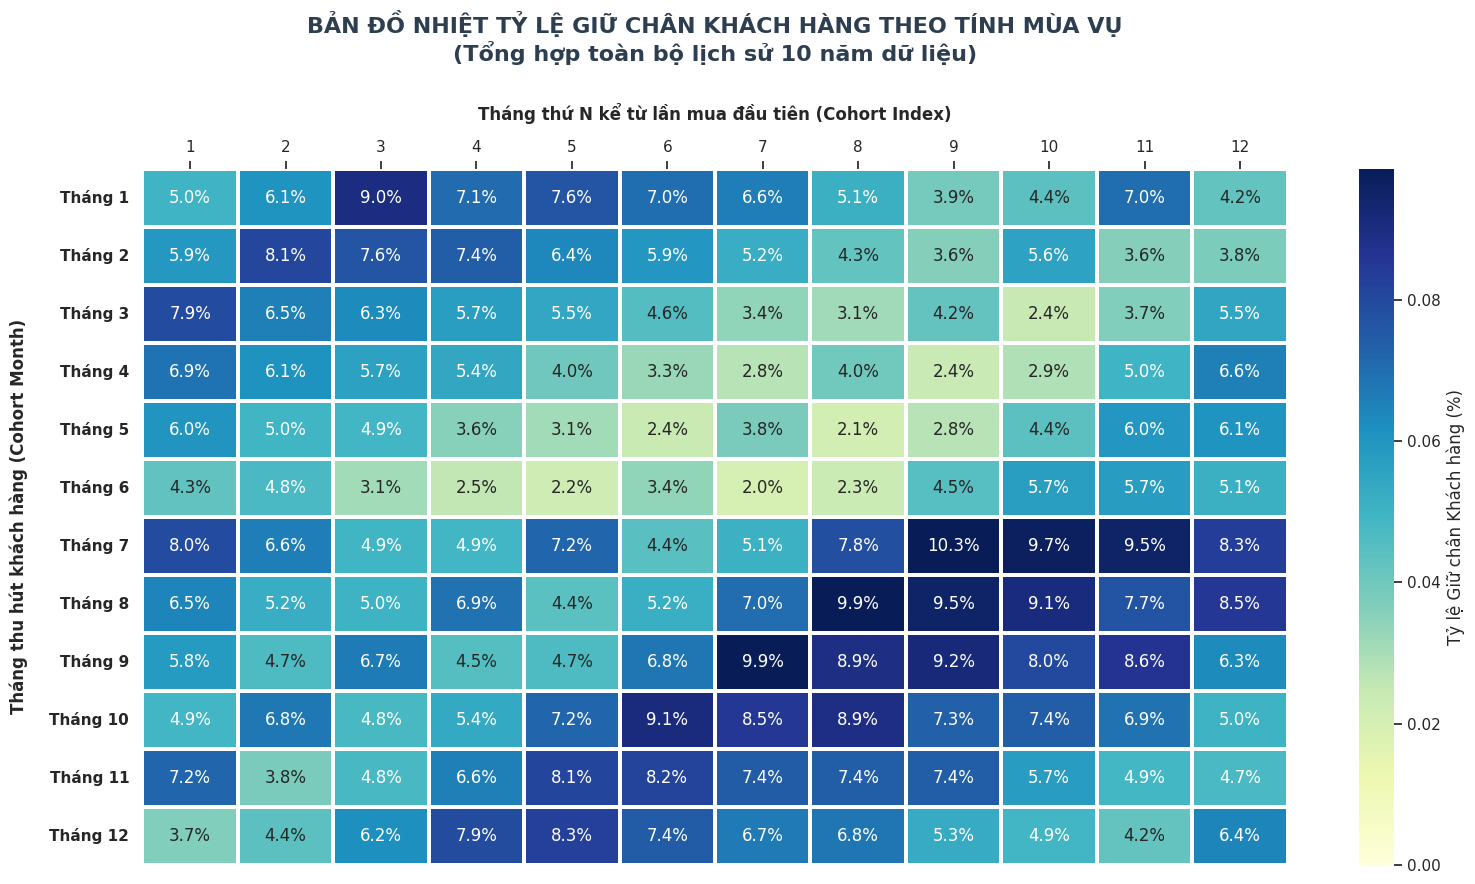

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. XÁC ĐỊNH THÁNG MUA HÀNG ĐẦU TIÊN (GỘP THEO MÙA)
# =========================================================
df_valid_orders = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid_orders['order_date'] = pd.to_datetime(df_valid_orders['order_date'])

# Tìm ngày mua hàng đầu tiên của từng khách hàng
first_purchases = df_valid_orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchases.rename(columns={'order_date': 'first_purchase_date'}, inplace=True)

# Ghép trở lại bảng gốc
df_valid_orders = pd.merge(df_valid_orders, first_purchases, on='customer_id')

# VŨ KHÍ BÍ MẬT: Trích xuất đúng THÁNG (1-12) của lần mua đầu tiên, bỏ qua Năm
df_valid_orders['Cohort_Month'] = df_valid_orders['first_purchase_date'].dt.month

# =========================================================
# 2. TÍNH KHOẢNG CÁCH THÁNG (COHORT INDEX)
# =========================================================
# Tính khoảng cách thực tế giữa ngày đặt hàng hiện tại và ngày mua đầu tiên
df_valid_orders['order_year'] = df_valid_orders['order_date'].dt.year
df_valid_orders['order_month'] = df_valid_orders['order_date'].dt.month
df_valid_orders['first_purchase_year'] = df_valid_orders['first_purchase_date'].dt.year
df_valid_orders['first_purchase_month'] = df_valid_orders['first_purchase_date'].dt.month

# Công thức tính số tháng trôi qua: (Năm sau - Năm trước)*12 + (Tháng sau - Tháng trước)
df_valid_orders['Cohort_Index'] = (df_valid_orders['order_year'] - df_valid_orders['first_purchase_year']) * 12 + \
                                  (df_valid_orders['order_month'] - df_valid_orders['first_purchase_month'])

# Để biểu đồ dễ nhìn, chúng ta chỉ theo dõi vòng đời trong 12 tháng đầu tiên
df_lifecycle = df_valid_orders[df_valid_orders['Cohort_Index'] <= 12].copy()

# =========================================================
# 3. XÂY DỰNG MA TRẬN & TÍNH TỶ LỆ GIỮ CHÂN
# =========================================================
# Đếm số lượng khách hàng độc nhất cho mỗi ô
cohort_data = df_lifecycle.groupby(['Cohort_Month', 'Cohort_Index'])['customer_id'].nunique()
cohort_counts = cohort_data.unstack(fill_value=0)

# Tính tỷ lệ % so với tháng 0
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Ánh xạ số tháng thành Tên tháng cho đẹp mắt
month_names = {1: 'Tháng 1', 2: 'Tháng 2', 3: 'Tháng 3', 4: 'Tháng 4', 
               5: 'Tháng 5', 6: 'Tháng 6', 7: 'Tháng 7', 8: 'Tháng 8', 
               9: 'Tháng 9', 10: 'Tháng 10', 11: 'Tháng 11', 12: 'Tháng 12'}
retention.index = retention.index.map(month_names)

# =========================================================
# 4. TRỰC QUAN HÓA BẰNG SEABORN HEATMAP
# =========================================================
plt.figure(figsize=(16, 9))
sns.set_theme(style="white")

# Vẽ Heatmap (Bỏ qua cột 0 vì nó luôn là 100%)
ax = sns.heatmap(retention.iloc[:, 1:], 
                 annot=True, 
                 fmt='.1%', 
                 vmin=0.0, 
                 vmax=retention.iloc[:, 1:].quantile(0.95).max(), # Đặt giới hạn màu động để tự hiển thị đẹp nhất
                 cmap='YlGnBu', 
                 linewidths=1.5, 
                 linecolor='white',
                 cbar_kws={'label': 'Tỷ lệ Giữ chân Khách hàng (%)'})

plt.title('BẢN ĐỒ NHIỆT TỶ LỆ GIỮ CHÂN KHÁCH HÀNG THEO TÍNH MÙA VỤ\n(Tổng hợp toàn bộ lịch sử 10 năm dữ liệu)', 
          fontsize=16, fontweight='black', pad=30, color='#2c3e50')

plt.ylabel('Tháng thu hút khách hàng (Cohort Month)', fontsize=12, fontweight='bold', labelpad=15)
plt.xlabel('Tháng thứ N kể từ lần mua đầu tiên (Cohort Index)', fontsize=12, fontweight='bold', labelpad=15)

# Đưa nhãn trục X lên phía trên
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.yticks(rotation=0, fontweight='bold')

plt.tight_layout()
plt.show()

### **Phân khúc Khách hàng theo Mô hình RFM (Recency, Frequency, Monetary)**

**1. Mục tiêu Phân tích**
Phân loại tập khách hàng dựa trên hành vi giao dịch thực tế để xác định các nhóm khách hàng giá trị, từ đó cá nhân hóa chiến dịch Marketing và tối ưu hóa ngân sách giữ chân khách hàng.

**2. Phương pháp Tính toán**
*   **Các chỉ số RFM cơ bản:**
    *   **Recency (R):** Số ngày kể từ lần mua hàng cuối cùng đến ngày chốt dữ liệu (snapshot). Điểm càng cao khi khách vừa mới mua hàng.
    *   **Frequency (F):** Tổng số đơn hàng độc nhất (unique orders) mà khách hàng đã thực hiện thành công.
    *   **Monetary (M):** Tổng doanh thu thuần (Net Revenue), tính bằng công thức: `(Số lượng * Đơn giá) - Giảm giá - Hoàn tiền`.
*   **Chấm điểm (RFM Scores):** Sử dụng phương pháp chia tứ phân vị (Quartiles) kết hợp xếp hạng để chia khách hàng vào 4 nhóm bằng nhau cho mỗi chỉ số R, F, M (thang điểm từ 1 đến 4).
*   **Phân nhóm (Segmentation):** Sử dụng hàm `np.select` để gộp các tổ hợp điểm R-F-M thành các nhóm định danh cụ thể như *Champions*, *Potential Loyals*, *At Risk*, hay *Hibernating*.
*   **Tỷ trọng (Share):** Tính toán phần trăm đóng góp về số lượng khách hàng (`customer_share`) và doanh thu (`rev_share`) của từng phân khúc trên tổng thể toàn hệ thống.

In [ ]:
import pandas as pd
import numpy as np

# =====================================================
# 1 & 2. CHUẨN BỊ DỮ LIỆU VÀ SNAPSHOT DATE
# =====================================================
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
snapshot_date = df_orders['order_date'].max()

# =====================================================
# 3. TINH CHẾ DỮ LIỆU RFM CẤP ĐỘ KHÁCH HÀNG
# =====================================================

# 1. Ép kiểu cục bộ 3 bảng liên quan
df_order_items['order_id'] = df_order_items['order_id'].astype(str)
df_order_items['product_id'] = df_order_items['product_id'].astype(str)

df_orders['order_id'] = df_orders['order_id'].astype(str)
df_orders['customer_id'] = df_orders['customer_id'].astype(str)

df_returns['order_id'] = df_returns['order_id'].astype(str)
df_returns['product_id'] = df_returns['product_id'].astype(str)
# Join dữ liệu y hệt left_join trong R
rfm_raw = pd.merge(df_order_items, df_orders[['order_id', 'customer_id', 'order_date']], on='order_id', how='left')
rfm_raw = pd.merge(rfm_raw, df_returns[['order_id', 'product_id', 'refund_amount']], on=['order_id', 'product_id'], how='left')

# Tính Net Revenue cho từng Item (Thay thế coalesce bằng fillna)
rfm_raw['discount_amount'] = rfm_raw['discount_amount'].fillna(0)
rfm_raw['refund_amount'] = rfm_raw['refund_amount'].fillna(0)
rfm_raw['net_revenue_item'] = (rfm_raw['quantity'] * rfm_raw['unit_price']) - rfm_raw['discount_amount'] - rfm_raw['refund_amount']

# Gom nhóm theo Customer (Summarise)
rfm_base = rfm_raw.groupby('customer_id').agg(
    last_purchase=('order_date', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('net_revenue_item', 'sum')
).reset_index()

# Tính Recency (Số ngày)
rfm_base['recency_days'] = (snapshot_date - rfm_base['last_purchase']).dt.days

# Lọc khách hàng có giá trị dương
rfm_base = rfm_base[rfm_base['monetary'] > 0].copy()

# =====================================================
# 4. TÍNH ĐIỂM RFM SCORES (1-4) - MÔ PHỎNG NTILE()
# =====================================================
# Dùng qcut kết hợp rank('first') để chia 4 phần bằng nhau y chang hàm ntile của dplyr
rfm_base['R_score'] = pd.qcut(rfm_base['recency_days'].rank(method='first', ascending=False), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_base['F_score'] = pd.qcut(rfm_base['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_base['M_score'] = pd.qcut(rfm_base['monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

# =====================================================
# 5. PHÂN NHÓM KHÁCH HÀNG VỚI NP.SELECT (THAY THẾ CASE_WHEN)
# =====================================================
conditions = [
    (rfm_base['R_score'] >= 3) & (rfm_base['F_score'] >= 3) & (rfm_base['M_score'] >= 3),
    (rfm_base['R_score'] >= 3) & (rfm_base['F_score'] >= 2),
    (rfm_base['R_score'] <= 2) & (rfm_base['M_score'] >= 3),
    (rfm_base['R_score'] <= 1) & (rfm_base['F_score'] <= 1)
]

choices = [
    "Champions",
    "Potential Loyals",
    "At Risk (Cần win-back)",
    "Hibernating (Ngủ đông)"
]

# np.select xử lý logic tuần tự và tốc độ như case_when
rfm_base['customer_segment'] = np.select(conditions, choices, default="New Customers")

# =====================================================
# 6. THỐNG KÊ SUMMARY & IN KẾT QUẢ
# =====================================================
rfm_summary = rfm_base.groupby('customer_segment').agg(
    customer_count=('customer_id', 'count'),
    total_net_rev=('monetary', 'sum')
).reset_index()

# Tính tỷ trọng
total_customers = rfm_summary['customer_count'].sum()
total_revenue = rfm_summary['total_net_rev'].sum()

rfm_summary['customer_share'] = rfm_summary['customer_count'] / total_customers
rfm_summary['rev_share'] = rfm_summary['total_net_rev'] / total_revenue

# Sắp xếp theo doanh thu giảm dần
rfm_summary = rfm_summary.sort_values(by='total_net_rev', ascending=False).reset_index(drop=True)

# Đẩy index bắt đầu từ 1 (Giống tibble trong R)
rfm_summary.index = rfm_summary.index + 1

# Lựa chọn cột và format số y hệt bảng bạn yêu cầu
format_dict = {
    'customer_share': '{:.3f}'.format,
    'rev_share': '{:.4f}'.format,
    'total_net_rev': '{:.1f}'.format
}

print("--- BẢNG TỔNG HỢP PHÂN KHÚC RFM ---")
print(rfm_summary[['customer_segment', 'customer_count', 'customer_share', 'total_net_rev', 'rev_share']].to_string(formatters=format_dict))

--- BẢNG TỔNG HỢP PHÂN KHÚC RFM ---
         customer_segment  customer_count customer_share total_net_rev rev_share
1               Champions           31753          0.352 11400792364.4    0.7515
2  At Risk (Cần win-back)           11091          0.123  1939783653.2    0.1279
3           New Customers           23782          0.264   886420196.4    0.0584
4        Potential Loyals            9915          0.110   660638662.9    0.0435
5  Hibernating (Ngủ đông)           13601          0.151   282790068.9    0.0186


In [ ]:
import plotly.express as px
import pandas as pd

# =========================================================
# 1. DỮ LIỆU THỰC TẾ (CẬP NHẬT THEO NET REVENUE)
# =========================================================
data = {
    'Segment': ['Champions', 'At Risk', 'Hibernating', 'Potential Loyals', 'New Customers'],
    'Count': [31753, 11091, 13601, 9915, 23782],
    # Điền trực tiếp cột total_net_rev vào đây
    'Total_Value': [11400792364.4, 1939783653.2, 282790068.9, 660638662.9, 886420196.4]
}
df = pd.DataFrame(data)

# Máy tự động tính lại mức chi tiêu trung bình để hiển thị khi di chuột (Hover)
df['Avg_Monetary'] = df['Total_Value'] / df['Count']

# =========================================================
# 2. VẼ BIỂU ĐỒ (PLOTLY CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

# Áp dụng bảng màu Corporate đồng bộ
corporate_colors = {
    'Champions': '#27AE60',        # Xanh Lục (Khỏe mạnh nhất)
    'At Risk': '#D35400',          # Đỏ Gạch (Báo động, cần cứu)
    'Hibernating': '#95A5A6',      # Xám xỉn (Đã rời đi)
    'Potential Loyals': '#4C72B0', # Xanh Dương (Đang phát triển)
    'New Customers': '#F39C12'     # Vàng Cam (Mới vào phễu)
}

fig = px.treemap(
    df, 
    path=['Segment'], 
    values='Total_Value',
    color='Segment',
    color_discrete_map=corporate_colors,
    custom_data=['Count', 'Avg_Monetary']
)

# =========================================================
# 3. TÙY CHỈNH TEXT VÀ HOVER HIỂN THỊ
# =========================================================
fig.update_traces(
    texttemplate="<span style='font-size:18px'><b>%{label}</b></span><br>" +
                 "<span style='font-size:14px'>%{percentParent:.1%} Doanh thu</span><br>" +
                 "<span style='font-size:13px'>(%{customdata[0]:,} KH)</span>",
    textposition="middle center",
    textfont=dict(family=vietnamese_font),
    hovertemplate="<b>Phân khúc: %{label}</b><br>" +
                  "Tổng Doanh thu: <b>%{value:,.0f}</b> VNĐ<br>" +
                  "Chi tiêu TB: <b>%{customdata[1]:,.0f}</b> VNĐ<extra></extra>"
)

# =========================================================
# 4. TINH CHỈNH LAYOUT (CORPORATE BACKGROUND & TITLE)
# =========================================================
fig.update_layout(
    title={
        'text': "<b>PHÂN BỔ GIÁ TRỊ KHÁCH HÀNG THEO TẬP RFM (CHUẨN NET REVENUE)</b><br><span style='font-size:14px; color:gray'>Kích thước ô thể hiện tỷ trọng Doanh thu thuần mang lại từ mỗi phân khúc</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    paper_bgcolor='#F7F8FA', # Nền xám ngà Corporate
    plot_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    margin=dict(t=90, l=20, r=20, b=20),
    width=1100, height=600
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 1. TÍNH TOÁN DATA: CHUẨN HÓA NET REVENUE VÀ LỢI NHUẬN THỰC
# =========================================================
# Ép kiểu dữ liệu chống trượt Merge cho cả order_id VÀ product_id
df_order_items['order_id'] = df_order_items['order_id'].astype(str)
df_returns['order_id'] = df_returns['order_id'].astype(str)

df_order_items['product_id'] = df_order_items['product_id'].astype(str)
df_products['product_id'] = df_products['product_id'].astype(str)
df_returns['product_id'] = df_returns['product_id'].astype(str)
df_inventory['product_id'] = df_inventory['product_id'].astype(str)

# A. Xử lý dữ liệu Trả hàng (Refunds & Returns)
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# B. Tính toán chỉ số Net tại mức độ từng dòng (Line Item)
df_items = pd.merge(df_order_items, df_products[['product_id', 'cogs', 'price']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

# Công thức Chuẩn:
df_items['Gross_Revenue'] = df_items['quantity'] * df_items['unit_price']
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity'] # Chỉ tính hàng không bị trả
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs'] # Vốn của hàng thực bán
df_items['Total_Gross_Profit'] = df_items['Net_Revenue'] - df_items['Total_COGS']

# C. Gom nhóm toàn bộ dữ liệu về mức độ Sản phẩm (Product Level)
product_level = df_items.groupby('product_id').agg(
    Total_Volume=('Net_Volume', 'sum'),
    Total_Revenue=('Net_Revenue', 'sum'),
    Total_COGS=('Total_COGS', 'sum'),
    Total_Gross_Profit=('Total_Gross_Profit', 'sum')
).reset_index()

# D. Ghép với bảng Tồn kho (Inventory)
inv_metrics = df_inventory.groupby('product_id').agg(
    avg_stock_on_hand=('stock_on_hand', 'mean'),
    sell_through_rate=('sell_through_rate', 'mean')
).reset_index()

# Tạo bảng Master cho việc Phân khúc (Lấy toàn bộ Product gốc làm gốc)
# Cập nhật lại df_seg để có product_name
df_seg = pd.merge(
    df_products[['product_id', 'product_name', 'category', 'cogs', 'price']], # Thêm product_name
    product_level, 
    on='product_id', 
    how='left'
)
# Các bước merge với inv_metrics và tính Margin_Pct giữ nguyên...
df_seg = pd.merge(df_seg, inv_metrics, on='product_id', how='left')
# Điền 0 cho các sản phẩm chưa phát sinh giao dịch hoặc dữ liệu
fill_cols = ['Total_Volume', 'Total_Revenue', 'Total_COGS', 'Total_Gross_Profit', 'avg_stock_on_hand', 'sell_through_rate']
df_seg[fill_cols] = df_seg[fill_cols].fillna(0)

# E. Tính Tỷ suất Lợi nhuận (Margin %) THỰC TẾ
# Dùng lợi nhuận thực tế chia doanh thu thuần. Nếu chưa bán được thì lấy margin lý thuyết (price - cogs) / price
df_seg['Margin_Pct'] = np.where(
    df_seg['Total_Revenue'] > 0,
    df_seg['Total_Gross_Profit'] / df_seg['Total_Revenue'],
    (df_seg['price'] - df_seg['cogs']) / df_seg['price']
)

# Tính vốn tồn kho để lát tính GMROI
df_seg['Avg_Inventory_Cost'] = df_seg['avg_stock_on_hand'] * df_seg['cogs']

# =========================================================
# 2. XÁC ĐỊNH MỐC TRUNG VỊ (MEDIAN) ĐỂ PHÂN KHÚC
# =========================================================
sold_items = df_seg[df_seg['Total_Volume'] > 0]
median_vol = sold_items['Total_Volume'].median()
median_margin = sold_items['Margin_Pct'].median()

# =========================================================
# 3. PHÂN KHÚC ĐỘNG THEO MA TRẬN 4 GÓC
# =========================================================
conditions = [
    (df_seg['Total_Volume'] <= 0), # Gộp cả trường hợp bán bị trả lại hết (<0)
    (df_seg['Total_Volume'] >= median_vol) & (df_seg['Margin_Pct'] >= median_margin),
    (df_seg['Total_Volume'] >= median_vol) & (df_seg['Margin_Pct'] < median_margin),
    (df_seg['Total_Volume'] > 0) & (df_seg['Total_Volume'] < median_vol) & (df_seg['Margin_Pct'] >= median_margin),
    (df_seg['Total_Volume'] > 0) & (df_seg['Total_Volume'] < median_vol) & (df_seg['Margin_Pct'] < median_margin)
]

choices = [
    '0. Unsold/Returned', 
    '1. Cash Cow ', 
    '2. Traffic Builder', 
    '3. Niche', 
    '4. Dead Weight'
]

df_seg['strategic_segment'] = np.select(conditions, choices, default='5. Standard')

# =========================================================
# 4. TỔNG HỢP SUMMARY & TÍNH GMROI
# =========================================================
summary = df_seg.groupby('strategic_segment').agg(
    SKU_Count=('product_id', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Total_COGS=('Total_COGS', 'sum'), 
    Total_Gross_Profit=('Total_Gross_Profit', 'sum'),
    Total_Avg_Inv_Cost=('Avg_Inventory_Cost', 'sum'), 
    Avg_Sell_Through_Rate=('sell_through_rate', 'mean')
).reset_index()

# Tính Tỷ trọng %
total_rev = summary['Total_Revenue'].sum()
total_gp = summary['Total_Gross_Profit'].sum()
summary['% Revenue'] = (summary['Total_Revenue'] / total_rev) * 100
summary['% Gross Profit'] = (summary['Total_Gross_Profit'] / total_gp) * 100

# Tính GMROI (Xử lý an toàn tránh lỗi chia cho 0)
summary['GMROI'] = summary['Total_Gross_Profit'] / summary['Total_Avg_Inv_Cost']
summary['GMROI'] = summary['GMROI'].replace([np.inf, -np.inf], 0).fillna(0)

# =========================================================
# 5. ĐỊNH DẠNG BẢNG ĐỂ IN RA (FORMATTING)
# =========================================================
summary['Total_Revenue'] = summary['Total_Revenue'].apply(lambda x: f"{x:,.0f} VNĐ")
summary['Total_COGS'] = summary['Total_COGS'].apply(lambda x: f"{x:,.0f} VNĐ")
summary['Total_Gross_Profit'] = summary['Total_Gross_Profit'].apply(lambda x: f"{x:,.0f} VNĐ")
summary['% Revenue'] = summary['% Revenue'].apply(lambda x: f"{x:.2f}%")
summary['% Gross Profit'] = summary['% Gross Profit'].apply(lambda x: f"{x:.2f}%")
summary['Avg_Sell_Through_Rate'] = summary['Avg_Sell_Through_Rate'].apply(lambda x: f"{x * 100:.2f}%")
summary['GMROI'] = summary['GMROI'].apply(lambda x: f"{x:.2f}x")

# Lựa chọn & sắp xếp cột
cols_to_show = [
    'strategic_segment', 'SKU_Count', 'Total_Revenue', 'Total_COGS', 
    'Total_Gross_Profit', '% Revenue', '% Gross Profit', 
    'Avg_Sell_Through_Rate', 'GMROI'
]
summary = summary[cols_to_show]

print("="*130)
print("BẢNG TÓM TẮT PHÂN KHÚC CHIẾN LƯỢC SẢN PHẨM (CHUẨN NET REVENUE)")
print("="*130)
print(summary.to_string(index=False))
print("="*130)

BẢNG TÓM TẮT PHÂN KHÚC CHIẾN LƯỢC SẢN PHẨM (CHUẨN NET REVENUE)
 strategic_segment  SKU_Count     Total_Revenue        Total_COGS Total_Gross_Profit % Revenue % Gross Profit Avg_Sell_Through_Rate  GMROI
0. Unsold/Returned        814             0 VNĐ             0 VNĐ              0 VNĐ     0.00%          0.00%                 0.80%  0.00x
      1. Cash Cow         380 6,183,188,012 VNĐ 4,531,537,064 VNĐ  1,651,650,949 VNĐ    40.76%        111.40%                15.59%  8.08x
2. Traffic Builder        420 8,400,574,493 VNĐ 8,647,772,971 VNĐ   -247,198,478 VNĐ    55.38%        -16.67%                15.53% -0.67x
          3. Niche        419   326,604,276 VNĐ   240,258,918 VNĐ     86,345,357 VNĐ     2.15%          5.82%                24.39%  4.89x
    4. Dead Weight        379   259,842,165 VNĐ   268,041,955 VNĐ     -8,199,790 VNĐ     1.71%         -0.55%                24.55% -0.38x


In [ ]:
import plotly.express as px

# =========================================================
# 1. CHUẨN BỊ DỮ LIỆU ĐỂ VẼ
# =========================================================
# Lọc bỏ nhóm Unsold/Returned để biểu đồ không bị dồn cục ở tọa độ (0,0)
plot_df = df_seg[df_seg['strategic_segment'] != '0. Unsold/Returned'].copy()

# Đổi Margin sang dạng % (nhân 100) để vẽ trục Y
plot_df['Margin_Pct_View'] = plot_df['Margin_Pct'] * 100
median_margin_view = median_margin * 100

# =========================================================
# 2. VẼ BIỂU ĐỒ (PLOTLY CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

# Đồng bộ bảng màu với biểu đồ Treemap trước đó
corporate_colors = {
    '1. Cash Cow ': '#27AE60',       # Xanh Lục (Khỏe mạnh, sinh lời)
    '2. Traffic Builder': '#4C72B0', # Xanh Dương (Sản lượng cao, ổn định)
    '3. Niche': '#F39C12',           # Vàng Cam (Lợi nhuận cao nhưng kén khách)
    '4. Dead Weight': '#D35400'      # Đỏ Gạch (Báo động/Thanh lý)
}

fig = px.scatter(
    plot_df,
    x='Total_Volume',
    y='Margin_Pct_View',
    color='strategic_segment',
    color_discrete_map=corporate_colors,
    custom_data=['product_id', 'Total_Revenue', 'Total_Gross_Profit'],
    labels={'strategic_segment': 'Phân khúc Chiến lược'}
)

# ---------------------------------------------------------
# TÙY CHỈNH MARKERS VÀ HOVER HIỂN THỊ
# ---------------------------------------------------------
fig.update_traces(
    marker=dict(size=9, opacity=0.75, line=dict(width=0.5, color='white')),
    hovertemplate="<b>SKU: %{customdata[0]}</b><br>" +
                  "Sản lượng (Net Vol): <b>%{x:,.0f}</b><br>" +
                  "Tỷ suất LNG: <b>%{y:.2f}%</b><br>" +
                  "Doanh thu thuần: %{customdata[1]:,.0f} VNĐ<br>" +
                  "Lợi nhuận gộp: %{customdata[2]:,.0f} VNĐ<extra></extra>"
)

# ---------------------------------------------------------
# THÊM ĐƯỜNG TRUNG VỊ (CẮT 4 GÓC MA TRẬN)
# ---------------------------------------------------------
fig.add_hline(y=median_margin_view, line_dash="dash", line_color="#7F8C8D", line_width=1.5, opacity=0.8)
fig.add_vline(x=median_vol, line_dash="dash", line_color="#7F8C8D", line_width=1.5, opacity=0.8)

# ---------------------------------------------------------
# TINH CHỈNH CORPORATE LAYOUT
# ---------------------------------------------------------
fig.update_layout(
    title={
        'text': "<b>MA TRẬN PHÂN KHÚC CHIẾN LƯỢC SẢN PHẨM (PRODUCT PORTFOLIO MATRIX)</b><br><span style='font-size:14px; color:gray'>Phân bổ SKU dựa trên Sản lượng bán ra và Tỷ suất Lợi nhuận gộp</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA', # Nền xám ngà
    font=dict(family=vietnamese_font, color='#2C3E50'),
    margin=dict(t=90, b=60, l=60, r=60),
    width=1200, height=700,
    
    # Kéo Legend (Chú giải) vào bên trong khung đồ thị cho gọn
    legend=dict(
        title="<b>Phân khúc Chiến lược</b>",
        bgcolor='rgba(247, 248, 250, 0.9)',
        bordercolor='#E5E8E8',
        borderwidth=1,
        yanchor="top", y=0.98, 
        xanchor="right", x=0.99
    )
)

# Cấu hình Trục X
fig.update_xaxes(
    title_text="<b>Tổng số lượng bán ra (Net Volume)</b>",
    showgrid=True, gridcolor='#E5E8E8', zeroline=False,
    tickformat=",.0f"
)

# Cấu hình Trục Y
fig.update_yaxes(
    title_text="<b>Tỷ suất Lợi nhuận gộp (%)</b>",
    showgrid=True, gridcolor='#E5E8E8', zeroline=False,
    tickformat=".0f", ticksuffix="%",
    # Khóa dải trục Y lại một chút nếu có outlier bị âm quá sâu (Loss Leader) làm móp biểu đồ
    range=[plot_df['Margin_Pct_View'].quantile(0.01) - 5, plot_df['Margin_Pct_View'].quantile(0.99) + 5] 
)

fig.show()

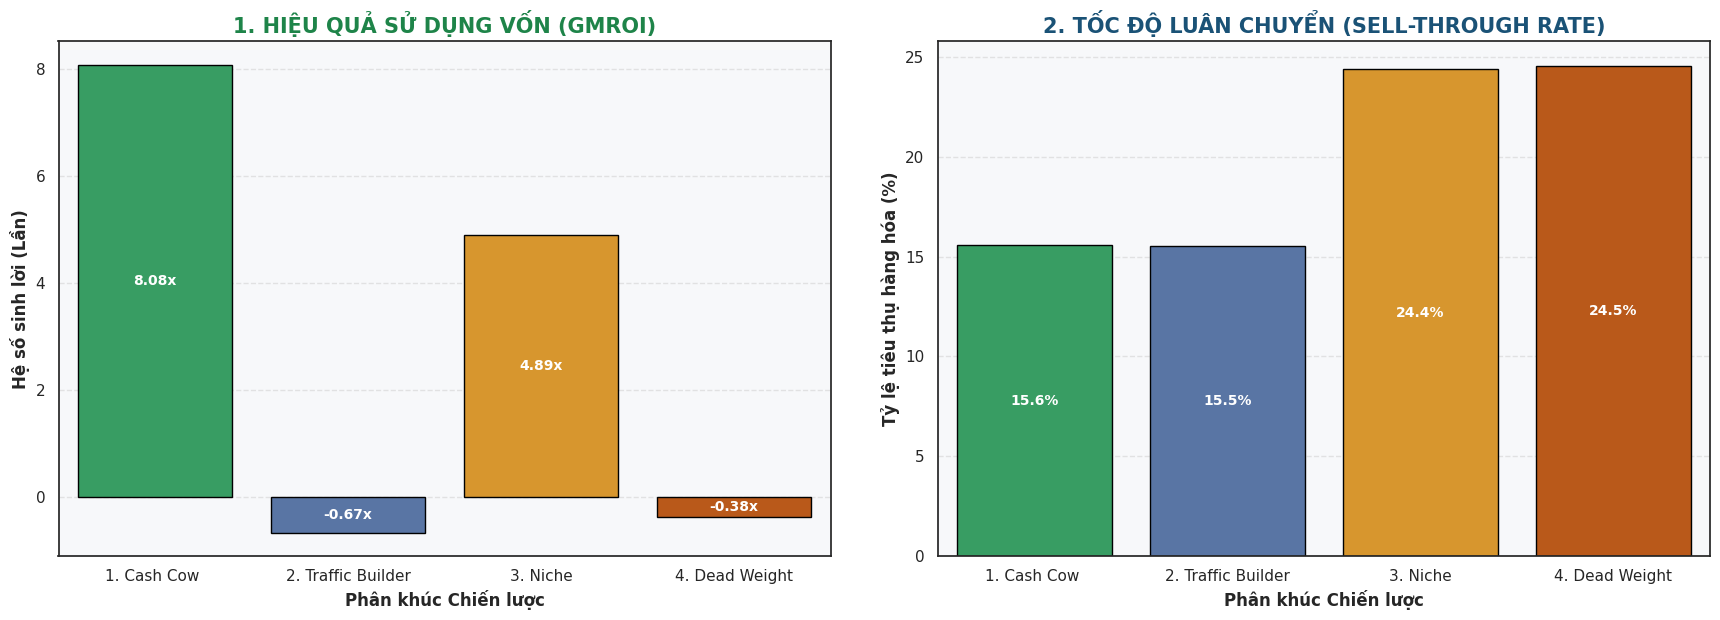

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. CHUẨN BỊ DỮ LIỆU (GIỮ NGUYÊN LOGIC CŨ)
# =========================================================
df_plot_summary = df_seg.groupby('strategic_segment').agg(
    Total_Gross_Profit=('Total_Gross_Profit', 'sum'),
    Total_Avg_Inv_Cost=('Avg_Inventory_Cost', 'sum'),
    Avg_Sell_Through_Rate=('sell_through_rate', 'mean')
).reset_index()

df_plot_summary['GMROI'] = df_plot_summary['Total_Gross_Profit'] / df_plot_summary['Total_Avg_Inv_Cost']
df_plot_summary['GMROI'] = df_plot_summary['GMROI'].replace([np.inf, -np.inf], 0).fillna(0)
df_plot_summary['Avg_Sell_Through_Rate_%'] = df_plot_summary['Avg_Sell_Through_Rate'] * 100

df_plot_summary = df_plot_summary[df_plot_summary['strategic_segment'] != '0. Unsold/Returned'].copy()

segment_colors = {
    '1. Cash Cow ': '#27AE60',
    '2. Traffic Builder': '#4C72B0',
    '3. Niche': '#F39C12',
    '4. Dead Weight': '#D35400'
}

# =========================================================
# 2. VẼ BIỂU ĐỒ - CẬP NHẬT VỊ TRÍ DATA LABELS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.rcParams['font.family'] = 'Arial'

# --- Biểu đồ 1: GMROI ---
sns.barplot(
    data=df_plot_summary, x='strategic_segment', y='GMROI', 
    hue='strategic_segment', palette=segment_colors, 
    ax=axes[0], edgecolor='black', legend=False
)
axes[0].set_title('1. HIỆU QUẢ SỬ DỤNG VỐN (GMROI)', fontsize=15, fontweight='bold', color='#1E8449')
axes[0].set_xlabel('Phân khúc Chiến lược', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Hệ số sinh lời (Lần)', fontsize=12, fontweight='bold')

# Đưa số vào giữa cột và thu nhỏ size
for p in axes[0].patches:
    height = p.get_height()
    # Tọa độ y là height/2 để nằm chính giữa hộp
    axes[0].annotate(f'{height:.2f}x', 
                     (p.get_x() + p.get_width() / 2., height / 2), 
                     ha='center', va='center', 
                     fontsize=10, fontweight='bold', color='white')

# --- Biểu đồ 2: Sell-Through Rate ---
sns.barplot(
    data=df_plot_summary, x='strategic_segment', y='Avg_Sell_Through_Rate_%', 
    hue='strategic_segment', palette=segment_colors, 
    ax=axes[1], edgecolor='black', legend=False
)
axes[1].set_title('2. TỐC ĐỘ LUÂN CHUYỂN (SELL-THROUGH RATE)', fontsize=15, fontweight='bold', color='#1A5276')
axes[1].set_xlabel('Phân khúc Chiến lược', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ tiêu thụ hàng hóa (%)', fontsize=12, fontweight='bold')

# Đưa số vào giữa cột và thu nhỏ size
for p in axes[1].patches:
    height = p.get_height()
    # Tọa độ y là height/2 để nằm chính giữa hộp
    axes[1].annotate(f'{height:.1f}%', 
                     (p.get_x() + p.get_width() / 2., height / 2), 
                     ha='center', va='center', 
                     fontsize=10, fontweight='bold', color='white')

for ax in axes:
    ax.set_facecolor('#F7F8FA')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()

### **Phân tích Giỏ hàng (Market Basket Analysis - MBA)**

**1. Mục tiêu Phân tích**
Đánh giá hiệu quả của nhóm sản phẩm "Mồi nhử" (Traffic Builder) trong việc lôi kéo khách hàng mua thêm các nhóm sản phẩm mang lại lợi nhuận cao như "Hàng đích" (Cash Cow) hoặc "Hàng ngách" (Niche) trong cùng một đơn hàng.

**2. Phương pháp Tính toán**
*   **Ma trận Giỏ hàng (Basket Matrix):** Sử dụng `pd.crosstab` để chuyển đổi dữ liệu giao dịch sang dạng ma trận Boolean (0 hoặc 1), xác định sự hiện diện của các phân khúc chiến lược trong mỗi đơn hàng.
*   **Xác suất cơ sở (Support):** Tỷ lệ đơn hàng chứa nhóm sản phẩm đó trên tổng số đơn hàng. Ký hiệu là $P(A)$ hoặc $P(B)$.
*   **Độ tin cậy (Confidence):** Thể hiện khả năng khách hàng sẽ mua thêm sản phẩm B khi đã có sản phẩm A trong giỏ hàng.
    *   *Công thức:* $Confidence (A \rightarrow B) = \frac{P(A \cap B)}{P(A)}$
*   **Độ nâng (Lift):** Đo lường mức độ ảnh hưởng của việc mua sản phẩm A đến khả năng mua sản phẩm B so với việc mua ngẫu nhiên.
    *   *Công thức:* $Lift (A \rightarrow B) = \frac{P(A \cap B)}{P(A) \times P(B)}$
    *   **Lift > 1:** Tác động tích cực (A giúp kéo B).
    *   **Lift = 1:** Ngẫu nhiên (A và B không liên quan).
    *   **Lift < 1:** Tác động tiêu cực (Khách mua A thường có xu hướng không mua B).

In [ ]:
import pandas as pd

# =========================================================
# 1. TẠO MA TRẬN GIỎ HÀNG (BASKET MATRIX)
# =========================================================
# Ghép phân khúc vào chi tiết đơn hàng
df_mba = pd.merge(df_order_items, df_seg[['product_id', 'strategic_segment']], 
                  on='product_id', how='inner')

# Lọc bỏ nhóm '0. Unsold' và '4. Dead Weight' (nếu bạn chỉ muốn focus vào kéo Cash Cow và Niche)
# Nhưng để chuẩn xác tổng số đơn, ta giữ nguyên toàn bộ dữ liệu lúc tạo ma trận
basket = pd.crosstab(df_mba['order_id'], df_mba['strategic_segment'])

# Chuyển đổi thành ma trận Boolean (1: Có mua, 0: Không mua)
basket = (basket > 0).astype(int)

# =========================================================
# 2. TÍNH TOÁN XÁC SUẤT VÀ CÁC CHỈ SỐ (CONFIDENCE, LIFT)
# =========================================================
total_orders = len(basket)

# Tập A: Traffic Builder
col_A = '2. Traffic Builder'
P_A = basket[col_A].sum() / total_orders

# Các tập B mục tiêu: Cash Cow và Niche
target_Bs = ['1. Cash Cow ', '3. Niche']
results = []

for col_B in target_Bs:
    # Xác suất mua B độc lập
    P_B = basket[col_B].sum() / total_orders
    
    # Xác suất giao (Mua cả A và B trong cùng 1 đơn)
    P_A_and_B = len(basket[(basket[col_A] == 1) & (basket[col_B] == 1)]) / total_orders
    
    # Tính Confidence và Lift
    confidence = P_A_and_B / P_A if P_A > 0 else 0
    lift = P_A_and_B / (P_A * P_B) if (P_A * P_B) > 0 else 0
    
    # Rút gọn tên cho đẹp
    name_B = col_B.split('. ')[1].strip()
    
    # Lưu kết quả
    results.append({
        'Luật kết hợp (A -> B)': f'Traffic Builder -> {name_B}',
        'P(A) - Đơn có Mồi nhử': P_A,
        'P(B) - Đơn có SP Đích': P_B,
        'P(A ∩ B) - Mua chung': P_A_and_B,
        'Confidence (Độ tin cậy)': confidence,
        'Lift (Độ nâng)': lift
    })

# =========================================================
# 3. TRÌNH BÀY BẢNG KẾT QUẢ ĐẦU RA
# =========================================================
df_lift = pd.DataFrame(results)

# Format lại bảng để hiển thị số phần trăm và làm tròn
df_display = df_lift.copy()
cols_to_pct = ['P(A) - Đơn có Mồi nhử', 'P(B) - Đơn có SP Đích', 'P(A ∩ B) - Mua chung', 'Confidence (Độ tin cậy)']
for col in cols_to_pct:
    df_display[col] = df_display[col].apply(lambda x: f"{x * 100:.2f}%")

df_display['Lift (Độ nâng)'] = df_display['Lift (Độ nâng)'].apply(lambda x: f"{x:.2f}")

print("="*110)
print("BÁO CÁO PHÂN TÍCH GIỎ HÀNG: HIỆU QUẢ KÉO KHÁCH CỦA NHÓM TRAFFIC BUILDER")
print("="*110)
print(df_display.to_string(index=False))
print("="*110)

# Nhận xét tự động dựa trên chỉ số Lift
print("\n[NHẬN XÉT NHANH TỪ HỆ THỐNG]")
for index, row in df_lift.iterrows():
    rule = row['Luật kết hợp (A -> B)']
    lift_val = row['Lift (Độ nâng)']
    conf_val = row['Confidence (Độ tin cậy)'] * 100
    
    if lift_val > 1:
        print(f"✅ {rule}: THÀNH CÔNG! Lift = {lift_val:.2f} (>1). Việc bán mồi nhử thực sự thúc đẩy khách mua thêm hàng lợi nhuận cao. Cụ thể, có {conf_val:.1f}% khách mua mồi nhử đã nhặt thêm hàng đích.")
    elif lift_val == 1:
        print(f"⚠️ {rule}: NGẪU NHIÊN! Lift = 1. Việc mua hai nhóm hàng này không liên quan gì đến nhau.")
    else:
        print(f"❌ {rule}: THẤT BẠI / TÁC DỤNG NGƯỢC! Lift = {lift_val:.2f} (<1). Khách mua mồi nhử xong thường có xu hướng bỏ qua, KHÔNG mua nhóm hàng đích này.")

BÁO CÁO PHÂN TÍCH GIỎ HÀNG: HIỆU QUẢ KÉO KHÁCH CỦA NHÓM TRAFFIC BUILDER
      Luật kết hợp (A -> B) P(A) - Đơn có Mồi nhử P(B) - Đơn có SP Đích P(A ∩ B) - Mua chung Confidence (Độ tin cậy) Lift (Độ nâng)
Traffic Builder -> Cash Cow                55.28%                47.34%                5.58%                  10.10%           0.21
   Traffic Builder -> Niche                55.28%                 1.74%                0.03%                   0.06%           0.03

[NHẬN XÉT NHANH TỪ HỆ THỐNG]
❌ Traffic Builder -> Cash Cow: THẤT BẠI / TÁC DỤNG NGƯỢC! Lift = 0.21 (<1). Khách mua mồi nhử xong thường có xu hướng bỏ qua, KHÔNG mua nhóm hàng đích này.
❌ Traffic Builder -> Niche: THẤT BẠI / TÁC DỤNG NGƯỢC! Lift = 0.03 (<1). Khách mua mồi nhử xong thường có xu hướng bỏ qua, KHÔNG mua nhóm hàng đích này.


In [ ]:
import plotly.graph_objects as go

# =========================================================
# 1. CHUẨN BỊ DỮ LIỆU TỪ BÁO CÁO
# =========================================================
labels = ['Traffic Builder -> Cash Cow', 'Traffic Builder -> Niche']
confidence = [10.10, 0.06]  # Tỷ lệ thực tế mua chung (%)
expected = [47.34, 1.74]    # Tỷ lệ mua tự nhiên P(B) (%)
lift = [0.21, 0.03]         # Chỉ số Lift

# =========================================================
# 2. VẼ BIỂU ĐỒ SO SÁNH THỰC TẾ VS KỲ VỌNG
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = go.Figure()

# Cột 1: Tỷ lệ mua tự nhiên (Kỳ vọng)
fig.add_trace(go.Bar(
    x=labels, y=expected,
    name='Tỷ lệ mua tự nhiên P(B) - Kỳ vọng',
    marker_color='#BDC3C7', opacity=0.6,
    text=[f"{v}%" for v in expected], textposition='outside'
))

# Cột 2: Tỷ lệ mua chung thực tế (Confidence)
fig.add_trace(go.Bar(
    x=labels, y=confidence,
    name='Độ tin cậy (Confidence) - Thực tế',
    marker_color='#E74C3C', # Màu đỏ cảnh báo thất bại
    text=[f"{v}%" for v in confidence], textposition='outside'
))

# ---------------------------------------------------------
# THÊM CHỈ SỐ LIFT LÀM ANNOTATION
# ---------------------------------------------------------
for i, l in enumerate(lift):
    fig.add_annotation(
        x=labels[i], y=max(expected[i], confidence[i]) + 5,
        text=f"<b>Lift = {l}</b><br>(Thất bại)",
        showarrow=False, font=dict(color='#C0392B', size=14)
    )

# ---------------------------------------------------------
# TINH CHỈNH LAYOUT CORPORATE
# ---------------------------------------------------------
fig.update_layout(
    title={
        'text': "<b>KIỂM ĐỊNH HIỆU QUẢ KÉO KHÁCH CỦA NHÓM MỒI NHỬ</b><br><span style='font-size:14px; color:gray'>Thực tế (Confidence) thấp hơn hẳn Kỳ vọng (P(B)) cho thấy chiến lược mồi nhử đang thất bại</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 18, 'color': '#1A2E46'}
    },
    barmode='group',
    plot_bgcolor='#F7F8FA', paper_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    yaxis_title="Tỷ lệ (%)",
    margin=dict(t=100, b=80, l=60, r=60),
    width=1000, height=600,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(range=[0, 60], ticksuffix="%")

fig.show()

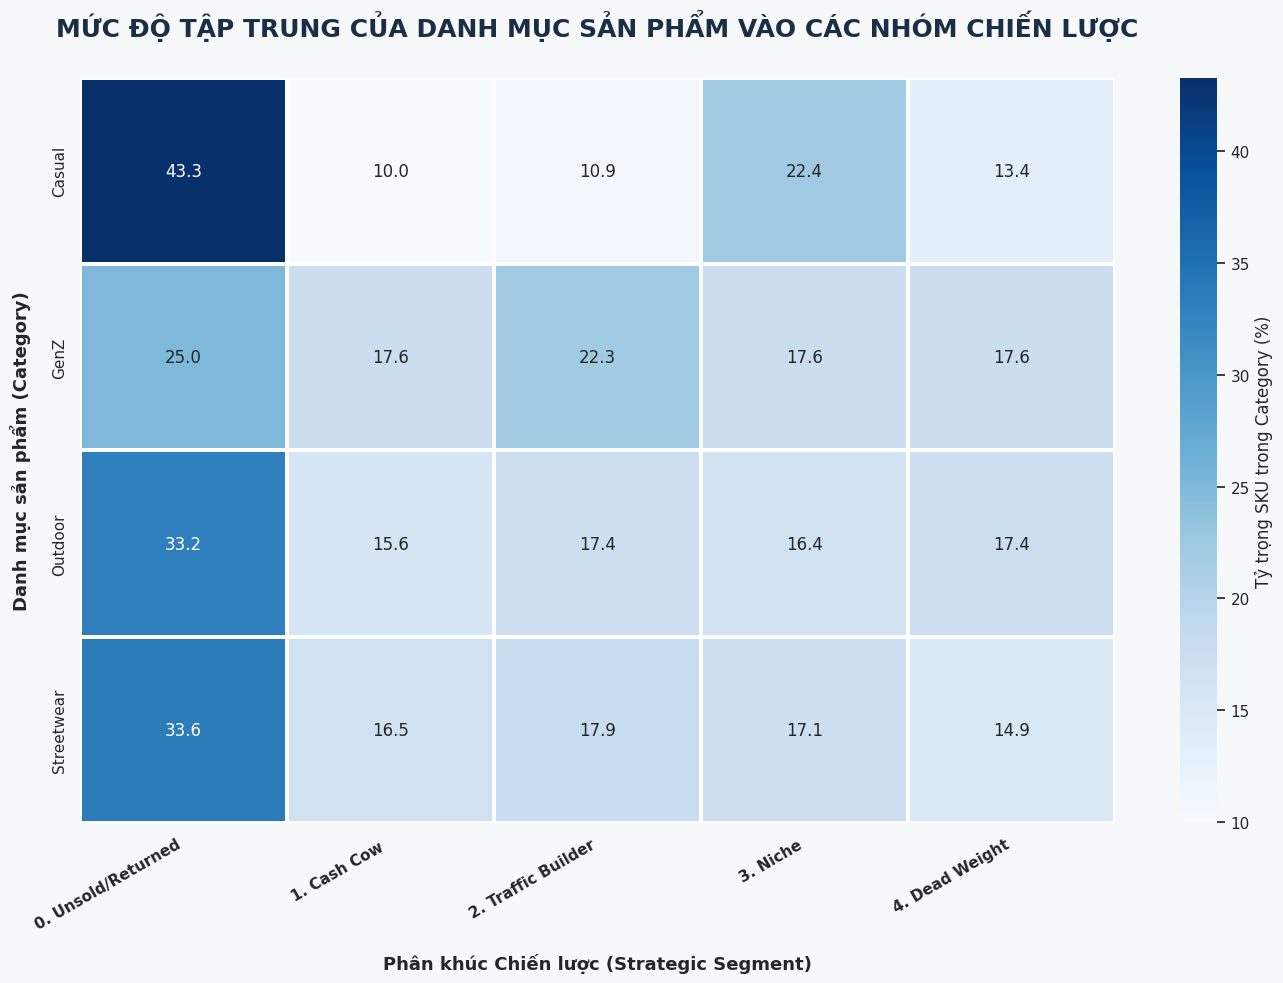

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 5. MA TRẬN PHÂN BỔ: CATEGORY NẰM Ở ĐÂU TRONG 4 NHÓM?
# =========================================================
# Tạo bảng chéo (Crosstab)
category_matrix = pd.crosstab(df_seg['category'], df_seg['strategic_segment'])

# Sắp xếp lại thứ tự cột cho logic từ 0 -> 4
desired_order = [
    '0. Unsold/Returned', 
    '1. Cash Cow ', 
    '2. Traffic Builder', 
    '3. Niche', 
    '4. Dead Weight'
]
existing_cols = [col for col in desired_order if col in category_matrix.columns]
category_matrix = category_matrix[existing_cols]

# Tính tỷ trọng % theo từng Category (dòng)
category_pct = category_matrix.div(category_matrix.sum(axis=1), axis=0) * 100

# =========================================================
# 6. TRỰC QUAN HÓA BẰNG HEATMAP (CORPORATE STYLE)
# =========================================================
plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(14, 10))
fig.set_facecolor('#F7F8FA')
ax.set_facecolor('#F7F8FA')

# Vẽ Heatmap
sns.heatmap(category_pct, 
            annot=True, 
            fmt=".1f", 
            cmap="Blues", 
            linewidths=1.5, 
            linecolor='white',
            cbar_kws={'label': 'Tỷ trọng SKU trong Category (%)'},
            ax=ax)

# Tinh chỉnh thẩm mỹ
plt.title('MỨC ĐỘ TẬP TRUNG CỦA DANH MỤC SẢN PHẨM VÀO CÁC NHÓM CHIẾN LƯỢC', 
          fontsize=18, fontweight='black', pad=30, color='#1A2E46')
plt.ylabel('Danh mục sản phẩm (Category)', fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel('Phân khúc Chiến lược (Strategic Segment)', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

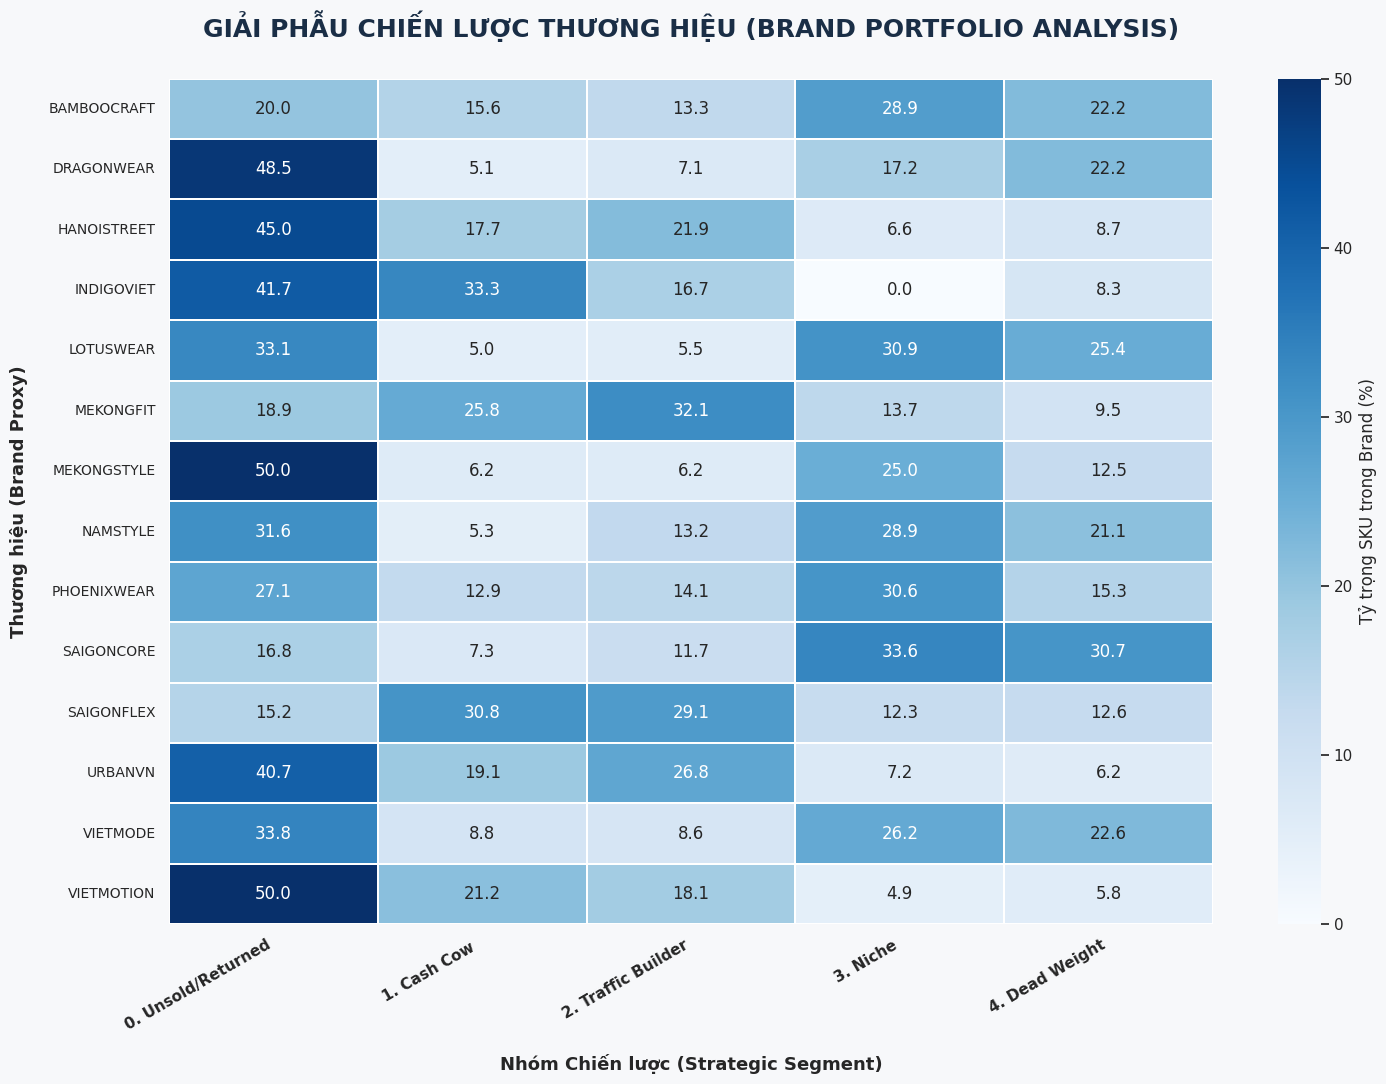

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. TRÍCH XUẤT BRAND PROXY & CHUẨN BỊ DATA
# =========================================================
# Trích xuất Brand và viết hoa để đồng nhất
df_seg['Brand_Proxy'] = df_seg['product_name'].apply(lambda x: str(x).split()[0].upper() if pd.notnull(x) else 'UNKNOWN')

# Lấy Top 20 Brand có SKU nhiều nhất
top_brands = df_seg['Brand_Proxy'].value_counts().nlargest(20).index
df_top_brands = df_seg[df_seg['Brand_Proxy'].isin(top_brands)].copy()

# Tạo ma trận chéo
brand_matrix = pd.crosstab(df_top_brands['Brand_Proxy'], df_top_brands['strategic_segment'])

# SẮP XẾP CỘT THEO THỨ TỰ LOGIC (0 -> 4)
desired_order = ['0. Unsold/Returned', '1. Cash Cow ', '2. Traffic Builder', '3. Niche', '4. Dead Weight']
existing_cols = [col for col in desired_order if col in brand_matrix.columns]
brand_matrix = brand_matrix[existing_cols]

# Tính tỷ trọng % theo từng Brand (hàng)
brand_pct = brand_matrix.div(brand_matrix.sum(axis=1), axis=0) * 100

# =========================================================
# 2. TRỰC QUAN HÓA HEATMAP (CORPORATE STYLE)
# =========================================================
plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(15, 11))
fig.set_facecolor('#F7F8FA')
ax.set_facecolor('#F7F8FA')

# Vẽ Heatmap
sns.heatmap(brand_pct, 
            annot=True, 
            fmt=".1f", 
            cmap="Blues", 
            linewidths=1.2, 
            linecolor='white',
            cbar_kws={'label': 'Tỷ trọng SKU trong Brand (%)'},
            ax=ax)

# Tinh chỉnh tiêu đề và nhãn theo phong cách báo cáo C-Level
plt.title('GIẢI PHẪU CHIẾN LƯỢC THƯƠNG HIỆU (BRAND PORTFOLIO ANALYSIS)', 
          fontsize=18, fontweight='black', pad=30, color='#1A2E46')
plt.ylabel('Thương hiệu (Brand Proxy)', fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel('Nhóm Chiến lược (Strategic Segment)', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

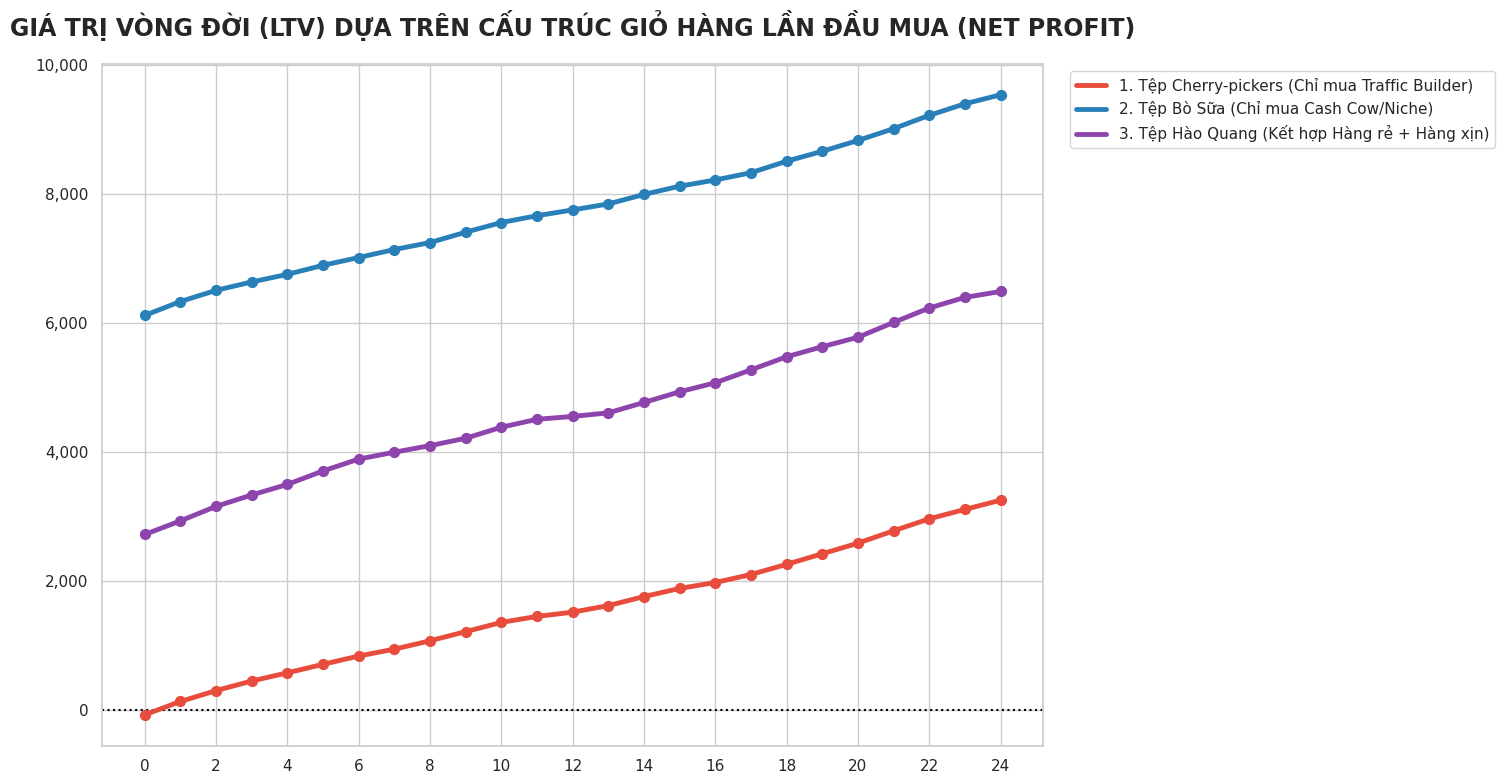

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================================================
# 1. TÍNH NET PROFIT (ĐÃ BAO GỒM HOÀN HÀNG)
# =========================================================
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_qty=('return_quantity', 'sum'),
    refund_amt=('refund_amount', 'sum')
).reset_index()

df_items = pd.merge(df_order_items, df_products[['product_id', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left').fillna(0)

# Công thức Net chuẩn
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_qty']
df_items['Net_Revenue'] = (df_items['quantity'] * df_items['unit_price']) - \
                           df_items['discount_amount'].fillna(0) - df_items['refund_amt']
df_items['Net_Profit'] = df_items['Net_Revenue'] - (df_items['Net_Volume'] * df_items['cogs'])

# Gom nhóm Profit theo đơn hàng
order_profit = df_items.groupby('order_id')['Net_Profit'].sum().reset_index()

# Lọc đơn thành công
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
df_valid = pd.merge(df_valid, order_profit, on='order_id', how='inner')

# =========================================================
# 2. PHÂN LOẠI TỆP KHÁCH HÀNG (VECTORIZED LOGIC)
# =========================================================
# Tìm đơn hàng đầu tiên
first_orders = df_valid.loc[df_valid.groupby('customer_id')['order_date'].idxmin()].copy()

# SỬA LỖI 1: Rename ngay tại đây để đồng bộ với bước 3
first_order_ids = first_orders[['customer_id', 'order_id', 'order_date']].copy()
first_order_ids.rename(columns={'order_date': 'first_purchase_date'}, inplace=True)

# Lấy các segment có trong giỏ hàng đầu tiên
first_basket = pd.merge(first_order_ids[['order_id', 'customer_id']], 
                        pd.merge(df_order_items, df_seg[['product_id', 'strategic_segment']], on='product_id'), 
                        on='order_id')

basket_check = first_basket.groupby(['customer_id', 'strategic_segment']).size().unstack(fill_value=0)

has_tb = basket_check.get('2. Traffic Builder', 0) > 0
has_core = (basket_check.get('1. Cash Cow ', 0) > 0) | (basket_check.get('3. Niche', 0) > 0)

conditions = [
    (has_tb & ~has_core),
    (~has_tb & has_core),
    (has_tb & has_core)
]
choices = [
    "1. Tệp Cherry-pickers (Chỉ mua Traffic Builder)",
    "2. Tệp Bò Sữa (Chỉ mua Cash Cow/Niche)",
    "3. Tệp Hào Quang (Kết hợp Hàng rẻ + Hàng xịn)"
]
basket_check['Cohort_Group'] = np.select(conditions, choices, default="Other")

# Merge lại nhóm vào tập khách hàng
cohort_mapping = basket_check[['Cohort_Group']].reset_index()
cohort_customers = pd.merge(first_order_ids, cohort_mapping, on='customer_id')
cohort_customers = cohort_customers[cohort_customers['Cohort_Group'] != "Other"]

# Lưu quy mô tệp để chia trung bình
cohort_sizes = cohort_customers.groupby('Cohort_Group')['customer_id'].nunique().to_dict()

# =========================================================
# 3. TÍNH LỢI NHUẬN TÍCH LŨY TRONG 24 THÁNG
# =========================================================
# Bây giờ first_purchase_date đã tồn tại trong index
df_analysis = pd.merge(df_valid, cohort_customers[['customer_id', 'first_purchase_date', 'Cohort_Group']], on='customer_id')

# Tính số tháng trôi qua (Cohort Index)
df_analysis['Cohort_Index'] = (df_analysis['order_date'].dt.year - df_analysis['first_purchase_date'].dt.year) * 12 + \
                              (df_analysis['order_date'].dt.month - df_analysis['first_purchase_date'].dt.month)

df_analysis = df_analysis[(df_analysis['Cohort_Index'] >= 0) & (df_analysis['Cohort_Index'] <= 24)]

# SỬA LỖI 2: Dùng 'Net_Profit' thay vì 'Order_Profit' để khớp với phần 1
profit_per_month = df_analysis.groupby(['Cohort_Group', 'Cohort_Index'])['Net_Profit'].sum().reset_index()

# Tạo khung lưới để fill các tháng trống
groups = profit_per_month['Cohort_Group'].unique()
indices = np.arange(0, 25)
grid = pd.MultiIndex.from_product([groups, indices], names=['Cohort_Group', 'Cohort_Index']).to_frame(index=False)

df_plot = pd.merge(grid, profit_per_month, on=['Cohort_Group', 'Cohort_Index'], how='left').fillna(0)
df_plot = df_plot.sort_values(['Cohort_Group', 'Cohort_Index'])

# Tính CỘNG DỒN và CHIA TRUNG BÌNH
df_plot['Cumulative_Profit'] = df_plot.groupby('Cohort_Group')['Net_Profit'].cumsum()
df_plot['Avg_Cum_Profit_Per_User'] = df_plot.apply(lambda r: r['Cumulative_Profit'] / cohort_sizes[r['Cohort_Group']], axis=1)

# =========================================================
# 4. TRỰC QUAN HÓA (GIỮ NGUYÊN STYLE CỦA BẠN)
# =========================================================
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#cccccc", "figure.facecolor": "white"})
fig, ax = plt.subplots(figsize=(15, 8))

styles = {
    "1. Tệp Cherry-pickers (Chỉ mua Traffic Builder)": {"color": "#e74c3c", "ls": "-", "lw": 3.5},
    "2. Tệp Bò Sữa (Chỉ mua Cash Cow/Niche)": {"color": "#2980b9", "ls": "-", "lw": 3.5},
    "3. Tệp Hào Quang (Kết hợp Hàng rẻ + Hàng xịn)": {"color": "#8e44ad", "ls": "-", "lw": 3.5}
}

for group, style in styles.items():
    if group in df_plot['Cohort_Group'].values:
        group_data = df_plot[df_plot['Cohort_Group'] == group]
        ax.plot(group_data['Cohort_Index'], group_data['Avg_Cum_Profit_Per_User'], 
                color=style["color"], linestyle=style["ls"], linewidth=style["lw"], label=group)
        ax.scatter(group_data['Cohort_Index'], group_data['Avg_Cum_Profit_Per_User'], 
                   color=style["color"], s=50, zorder=5)

ax.axhline(0, color='black', linewidth=1.5, linestyle=':', zorder=1)
ax.set_xticks(np.arange(0, 25, 2))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.set_title('GIÁ TRỊ VÒNG ĐỜI (LTV) DỰA TRÊN CẤU TRÚC GIỎ HÀNG LẦN ĐẦU MUA (NET PROFIT)', fontsize=17, fontweight='black', pad=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Phân tích Sinh tồn Khách hàng (Customer Survival Analysis)**

**1. Mục tiêu Phân tích**
So sánh "độ bền" và tốc độ rời bỏ của khách hàng giữa các nhóm gia nhập khác nhau để định lượng chất lượng tệp khách, từ đó tối ưu hóa ngân sách thu hút và chiến lược giữ chân.

**2. Phương pháp Tính toán**
*   **Tuổi thọ khách hàng (Lifespan):** Khoảng thời gian (tính bằng tháng) từ đơn hàng thành công đầu tiên đến đơn hàng cuối cùng của từng khách hàng định danh.
*   **Phân nhóm chiến lược (Cohort Group):** Phân loại khách hàng dựa trên đặc điểm của tháng và năm gia nhập (Ví dụ: nhóm "Thợ săn Sale" gia nhập vào mùa khuyến mãi, nhóm "Khách hàng Vàng" gia nhập vào các tháng có tỷ lệ giữ chân cao).
*   **Tỷ lệ sinh tồn (Survival Rate):** Tại mốc tháng thứ $n$, tỷ lệ này được tính bằng: `(Số khách hàng có tuổi thọ >= n) / (Tổng số khách hàng ban đầu của nhóm đó)`.
*   **Trực quan hóa:** Sử dụng đường cong sinh tồn (Survival Curve) để quan sát tốc độ rời bỏ; nhóm có đường biểu diễn dốc xuống càng nhanh thì tỷ lệ rời bỏ càng cao.
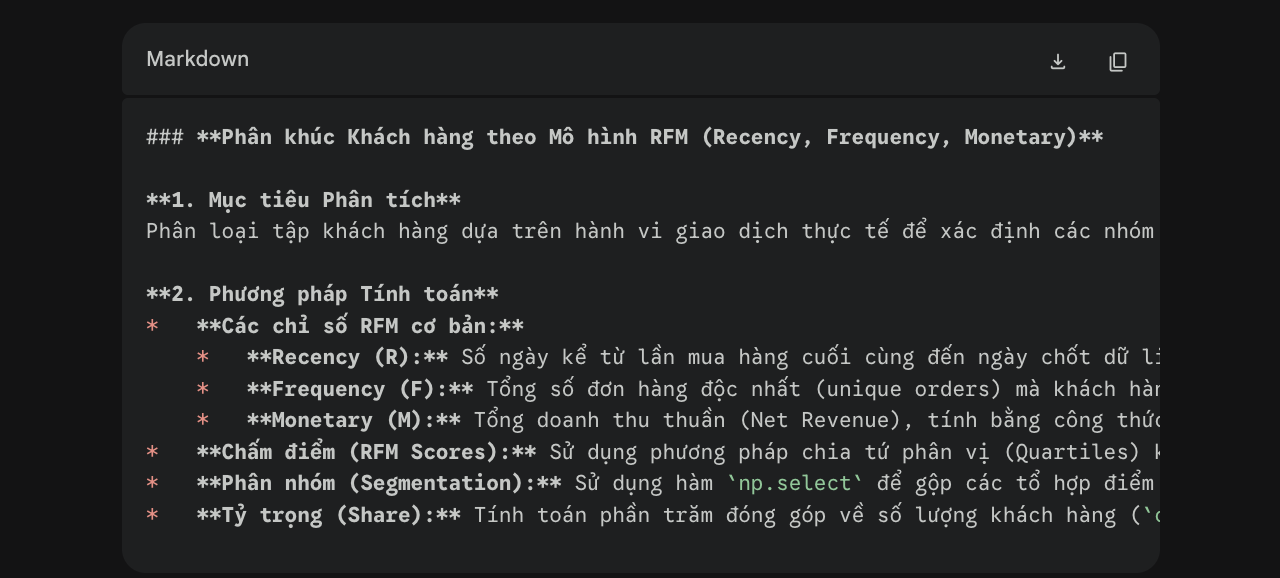

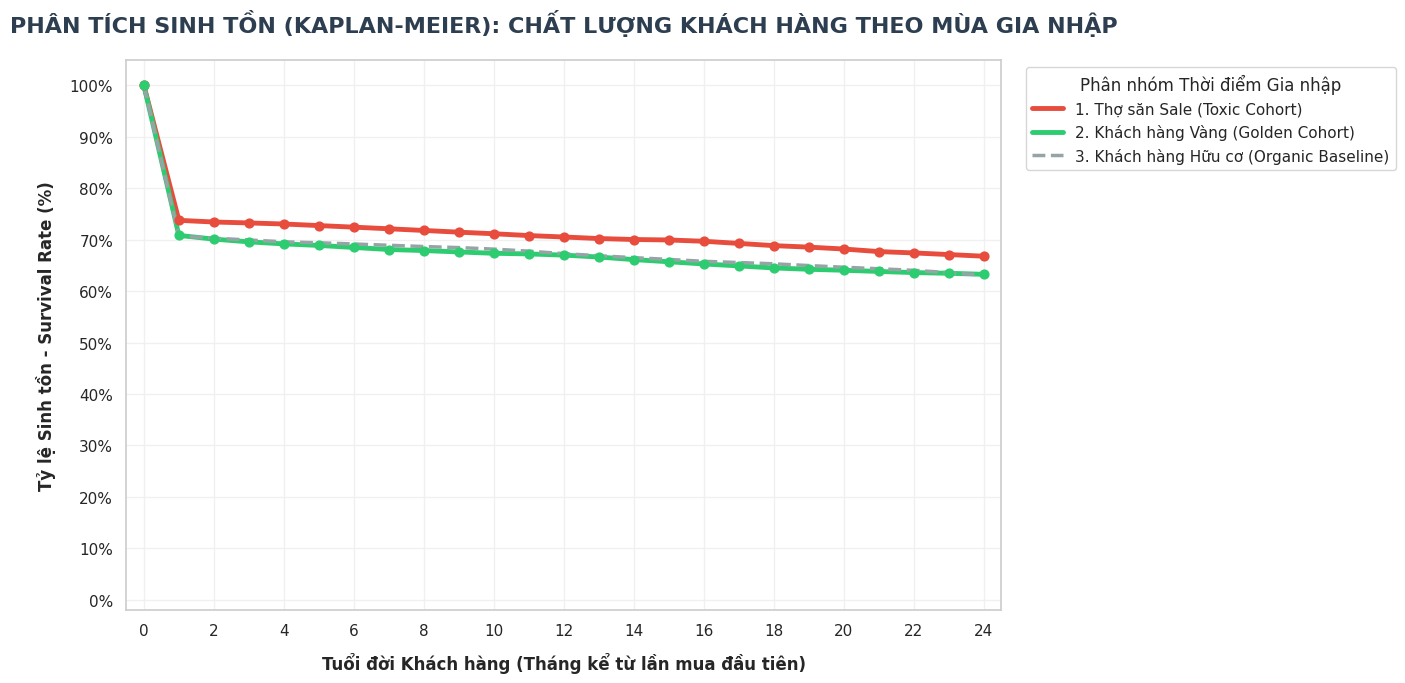

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. TRÍCH XUẤT TUỔI THỌ KHÁCH HÀNG (CUSTOMER LIFESPAN)
# =========================================================
# Chỉ tính những đơn hàng mua thành công
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])

# Tìm ngày mua đầu tiên và ngày mua cuối cùng của TỪNG khách hàng
customer_lifespan = df_valid.groupby('customer_id').agg(
    first_purchase=('order_date', 'min'),
    last_purchase=('order_date', 'max')
).reset_index()

# Lấy thông tin Tháng và Năm của lần mua đầu tiên
customer_lifespan['first_month'] = customer_lifespan['first_purchase'].dt.month
customer_lifespan['first_year'] = customer_lifespan['first_purchase'].dt.year

# Tính "Tuổi thọ" (Lifespan) bằng số tháng tính từ lần đầu đến lần cuối mua hàng
customer_lifespan['lifespan_months'] = (
    (customer_lifespan['last_purchase'].dt.year - customer_lifespan['first_purchase'].dt.year) * 12 +
    (customer_lifespan['last_purchase'].dt.month - customer_lifespan['first_purchase'].dt.month)
)

# =========================================================
# 2. PHÂN LOẠI 3 NHÓM CHIẾN LƯỢC THEO MÔ TẢ CỦA BẠN
# =========================================================
def classify_cohort(row):
    m = row['first_month']
    y = row['first_year']
    
    # Tệp "Thợ săn Sale" (Tháng 8 năm lẻ & Tháng 12)
    if m == 12 or (m == 8 and y % 2 != 0):
        return "1. Thợ săn Sale (Toxic Cohort)"
    # Tệp "Khách hàng Vàng" (Tháng 3)
    elif m == 3:
        return "2. Khách hàng Vàng (Golden Cohort)"
    # Tệp "Hữu cơ" (Tháng 2, 5, 6, 9)
    elif m in [2, 5, 6, 9]:
        return "3. Khách hàng Hữu cơ (Organic Baseline)"
    else:
        return "Other"

customer_lifespan['Cohort_Group'] = customer_lifespan.apply(classify_cohort, axis=1)

# Chỉ giữ lại 3 nhóm cần phân tích
df_analysis = customer_lifespan[customer_lifespan['Cohort_Group'] != 'Other'].copy()

# =========================================================
# 3. TÍNH TOÁN TỶ LỆ SINH TỒN (SURVIVAL RATE)
# =========================================================
max_months = 24 # Theo dõi trong vòng 24 tháng (2 năm)
survival_data = []

# Đếm tổng số khách hàng ban đầu và số người "còn sống" qua từng tháng
for group, group_df in df_analysis.groupby('Cohort_Group'):
    total_customers = len(group_df)
    for t in range(max_months + 1):
        # Khách hàng được coi là "còn sống" nếu tuổi thọ của họ >= t
        survivors = len(group_df[group_df['lifespan_months'] >= t])
        survival_rate = (survivors / total_customers) * 100
        survival_data.append({'Cohort_Group': group, 'Month': t, 'Survival_Rate': survival_rate})

df_survival = pd.DataFrame(survival_data)

# =========================================================
# 4. TRỰC QUAN HÓA BẰNG BIỂU ĐỒ SURVIVAL CURVE
# =========================================================
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#cccccc", "axes.linewidth": 1.2,
    "grid.color": "#f0f0f0", "figure.facecolor": "white"
})
fig, ax = plt.subplots(figsize=(14, 7))

# Thiết lập style đường vẽ theo đúng mô tả của bạn
styles = {
    "1. Thợ săn Sale (Toxic Cohort)": {"color": "#e74c3c", "ls": "-", "lw": 3.5},    # Đỏ, nét liền
    "2. Khách hàng Vàng (Golden Cohort)": {"color": "#2ecc71", "ls": "-", "lw": 3.5}, # Xanh lá, nét liền
    "3. Khách hàng Hữu cơ (Organic Baseline)": {"color": "#95a5a6", "ls": "--", "lw": 2.5} # Xám, nét đứt
}

for group in styles.keys():
    group_data = df_survival[df_survival['Cohort_Group'] == group]
    ax.plot(group_data['Month'], group_data['Survival_Rate'], 
            color=styles[group]["color"], 
            linestyle=styles[group]["ls"], 
            linewidth=styles[group]["lw"], 
            label=group)
    
    # Vẽ thêm các chấm nhỏ trên đường biểu diễn để dễ nhìn điểm neo
    if group != "3. Khách hàng Hữu cơ (Organic Baseline)":
        ax.scatter(group_data['Month'], group_data['Survival_Rate'], color=styles[group]["color"], s=40, zorder=5)

# =========================================================
# 5. CHÚ THÍCH & THẨM MỸ BÁO CÁO C-LEVEL
# =========================================================
# Cài đặt trục
ax.set_xticks(np.arange(0, 25, 2))
ax.set_yticks(np.arange(0, 110, 10))
ax.set_xlim(-0.5, 24.5)
ax.set_ylim(-2, 105)

# Nhãn trục
ax.set_xlabel('Tuổi đời Khách hàng (Tháng kể từ lần mua đầu tiên)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Tỷ lệ Sinh tồn - Survival Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('PHÂN TÍCH SINH TỒN (KAPLAN-MEIER): CHẤT LƯỢNG KHÁCH HÀNG THEO MÙA GIA NHẬP', 
             fontsize=16, fontweight='black', pad=20, color='#2c3e50')

# Format trục Y thành dạng %
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Highlight điểm rơi thảm hại của "Thợ săn Sale" tại Tháng thứ 1


# Bật hiển thị hộp bao quanh biểu đồ
for spine in ax.spines.values():
    spine.set_visible(True)

# Gắn Legend ra ngoài góc phải
plt.legend(title='Phân nhóm Thời điểm Gia nhập', title_fontsize=12, fontsize=11,
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

### **Đường cong Tài chính Khách hàng (Cumulative Profit per User)**

**1. Mục tiêu Phân tích**
Đo lường giá trị kinh tế thực tế khách hàng đóng góp theo thời gian (CLV), giúp xác định thời điểm hòa vốn và so sánh khả năng sinh lời giữa các nhóm khách hàng khác nhau để tối ưu hóa ngân sách Marketing.

**2. Phương pháp Tính toán**
*   **Lợi nhuận ròng (Net Profit):** Lợi nhuận thực tế trên từng đơn hàng, tính bằng: `Doanh thu thực thu - Giá vốn hàng bán (COGS) của lượng hàng khách giữ lại`.
*   **Phân nhóm chiến lược (Cohort Group):** Chia khách hàng dựa trên thời điểm gia nhập (ví dụ: *Toxic Cohort* vào mùa sale, *Golden Cohort* vào tháng có tỷ lệ giữ chân cao).
*   **Lợi nhuận tích lũy (Cumulative Profit):** Tổng lợi nhuận cộng dồn từ tháng đầu tiên đến tháng thứ $n$ của một nhóm khách hàng nhất định.
*   **Lợi nhuận trung bình/User (Avg Profit per User):** Lấy Lợi nhuận tích lũy chia cho **tổng số lượng khách hàng ban đầu** của nhóm đó. Việc giữ nguyên mẫu số ban đầu giúp phản ánh chính xác thiệt hại tài chính khi khách hàng rời bỏ.
*   **Đường hòa vốn (Break-even):** Mốc giá trị 0 trên trục tung; là thời điểm nhóm khách hàng bù đắp hết chi phí vốn ban đầu và bắt đầu sinh lời cho doanh nghiệp.

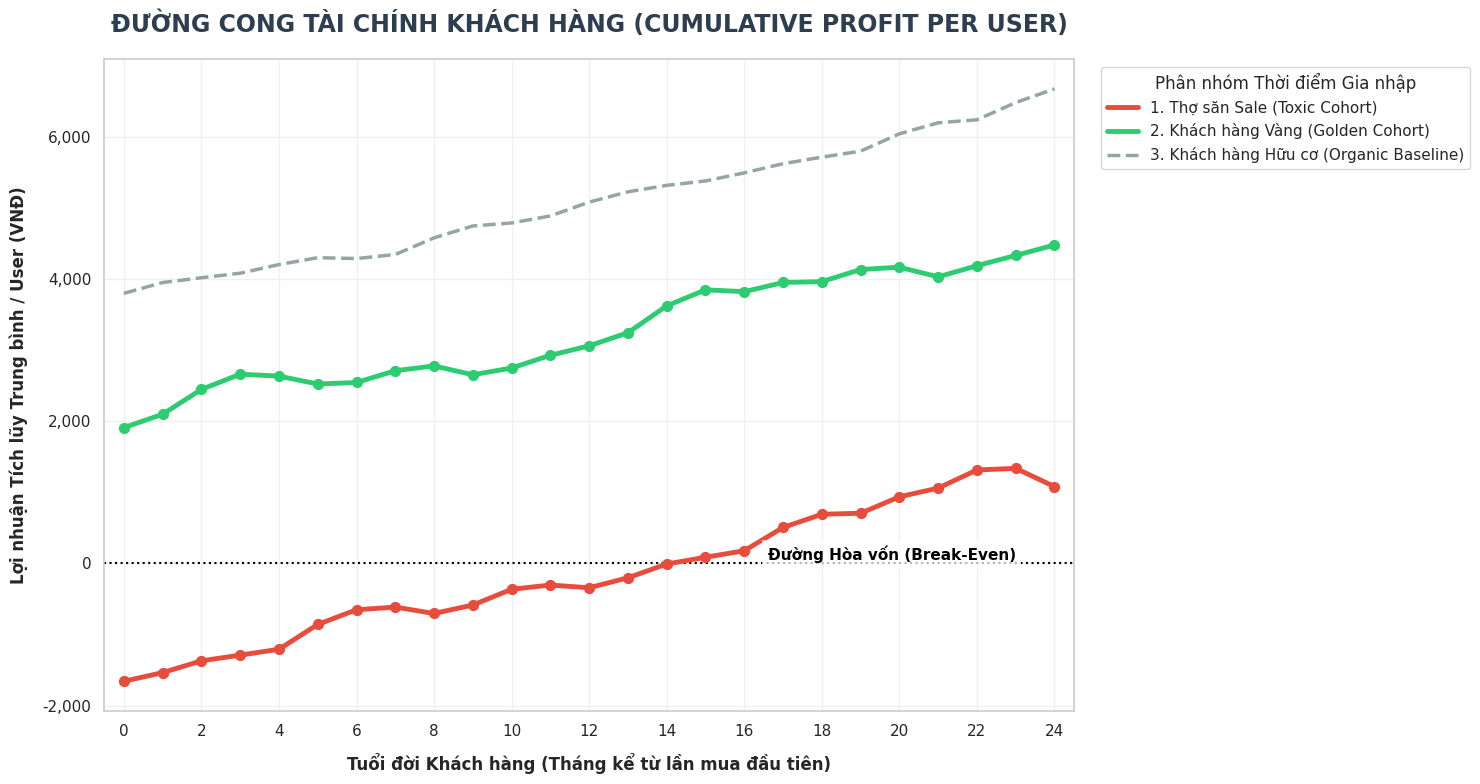

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick

# =========================================================
# 1. TÍNH TOÁN LỢI NHUẬN TRÊN TỪNG ĐƠN HÀNG (PROFIT PER ORDER)
# =========================================================
# =========================================================
# 1. TÍNH TOÁN LỢI NHUẬN THỰC TRÊN TỪNG ĐƠN HÀNG (NET PROFIT)
# =========================================================
# Ép kiểu để merge chính xác
df_order_items['order_id'] = df_order_items['order_id'].astype(str)
df_returns['order_id'] = df_returns['order_id'].astype(str)

# A. Lấy dữ liệu trả hàng (Returns)
df_returns_agg = df_returns.groupby(['order_id', 'product_id']).agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# B. Tính toán Profit theo công thức NET đã thống nhất
df_items = pd.merge(df_order_items, df_products[['product_id', 'cogs']], on='product_id', how='left')
df_items = pd.merge(df_items, df_returns_agg, on=['order_id', 'product_id'], how='left')

# Điền 0 cho những đơn không có trả hàng/giảm giá
df_items.fillna({'return_quantity': 0, 'refund_amount': 0, 'discount_amount': 0}, inplace=True)

# --- ÁP DỤNG CÔNG THỨC THỐNG NHẤT ---
# 1. Net Volume: Chỉ tính vốn cho hàng khách giữ lại
df_items['Net_Volume'] = df_items['quantity'] - df_items['return_quantity']
df_items['Total_COGS'] = df_items['Net_Volume'] * df_items['cogs']

# 2. Net Revenue: Doanh thu thực thu sau giảm giá và hoàn tiền
df_items['Gross_Revenue'] = df_items['quantity'] * df_items['unit_price']
df_items['Net_Revenue'] = df_items['Gross_Revenue'] - df_items['discount_amount'] - df_items['refund_amount']

# 3. Net Profit per Item: Lợi nhuận thực tế mang về
df_items['Item_Profit'] = df_items['Net_Revenue'] - df_items['Total_COGS']

# Gom nhóm lại cấp đơn hàng
order_profit = df_items.groupby('order_id')['Item_Profit'].sum().reset_index()
order_profit.rename(columns={'Item_Profit': 'Order_Profit'}, inplace=True)

# Lọc đơn thành công (không cancelled) và ghép vào
df_valid = df_orders[df_orders['order_status'] != 'cancelled'].copy()
df_valid['order_date'] = pd.to_datetime(df_valid['order_date'])
df_valid = pd.merge(df_valid, order_profit, on='order_id', how='inner')
# =========================================================
# 2. XÁC ĐỊNH COHORT VÀ KÍCH THƯỚC TẬP KHÁCH HÀNG
# =========================================================
# Lấy tháng mua đầu tiên của từng khách
first_purchases = df_valid.groupby('customer_id')['order_date'].min().reset_index()
first_purchases.rename(columns={'order_date': 'first_purchase_date'}, inplace=True)
first_purchases['first_month'] = first_purchases['first_purchase_date'].dt.month
first_purchases['first_year'] = first_purchases['first_purchase_date'].dt.year

def classify_cohort(row):
    m = row['first_month']
    y = row['first_year']
    if m == 12 or (m == 8 and y % 2 != 0):
        return "1. Thợ săn Sale (Toxic Cohort)"
    elif m == 3:
        return "2. Khách hàng Vàng (Golden Cohort)"
    elif m in [2, 5, 6, 9]:
        return "3. Khách hàng Hữu cơ (Organic Baseline)"
    return "Other"

first_purchases['Cohort_Group'] = first_purchases.apply(classify_cohort, axis=1)
cohort_customers = first_purchases[first_purchases['Cohort_Group'] != 'Other'].copy()

# LƯU Ý QUAN TRỌNG: Lưu lại tổng số user của từng nhóm để chia trung bình
# Dù khách hàng có bỏ đi ở tháng thứ 2, họ vẫn được tính vào mẫu số để tính trung bình
cohort_sizes = cohort_customers.groupby('Cohort_Group')['customer_id'].nunique().to_dict()

# =========================================================
# 3. TÍNH LỢI NHUẬN TÍCH LŨY THEO TỪNG THÁNG (COHORT INDEX)
# =========================================================
df_analysis = pd.merge(df_valid, cohort_customers[['customer_id', 'first_purchase_date', 'Cohort_Group']], on='customer_id', how='inner')

# Tính số tháng trôi qua (Cohort Index)
df_analysis['Cohort_Index'] = (df_analysis['order_date'].dt.year - df_analysis['first_purchase_date'].dt.year) * 12 + \
                              (df_analysis['order_date'].dt.month - df_analysis['first_purchase_date'].dt.month)

# Chỉ lấy trong biên độ 24 tháng
df_analysis = df_analysis[(df_analysis['Cohort_Index'] >= 0) & (df_analysis['Cohort_Index'] <= 24)]

# Tính TỔNG lợi nhuận mang lại trong từng tháng của từng nhóm
profit_per_month = df_analysis.groupby(['Cohort_Group', 'Cohort_Index'])['Order_Profit'].sum().reset_index()

# Tạo ma trận đầy đủ 25 tháng (0-24) để đảm bảo không bị khuyết tháng nào
groups = profit_per_month['Cohort_Group'].unique()
indices = np.arange(0, 25)
grid = pd.MultiIndex.from_product([groups, indices], names=['Cohort_Group', 'Cohort_Index']).to_frame(index=False)

df_plot = pd.merge(grid, profit_per_month, on=['Cohort_Group', 'Cohort_Index'], how='left').fillna(0)
df_plot = df_plot.sort_values(['Cohort_Group', 'Cohort_Index'])

# Tính CỘNG DỒN (Cumulative) và CHIA TRUNG BÌNH cho Tổng Users ban đầu
df_plot['Cumulative_Profit'] = df_plot.groupby('Cohort_Group')['Order_Profit'].cumsum()
df_plot['Avg_Cum_Profit_Per_User'] = df_plot.apply(lambda r: r['Cumulative_Profit'] / cohort_sizes[r['Cohort_Group']], axis=1)

# =========================================================
# 4. TRỰC QUAN HÓA BẰNG BIỂU ĐỒ TÀI CHÍNH
# =========================================================
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#cccccc", "axes.linewidth": 1.2,
    "grid.color": "#f0f0f0", "figure.facecolor": "white"
})
fig, ax = plt.subplots(figsize=(15, 8))

styles = {
    "1. Thợ săn Sale (Toxic Cohort)": {"color": "#e74c3c", "ls": "-", "lw": 3.5},
    "2. Khách hàng Vàng (Golden Cohort)": {"color": "#2ecc71", "ls": "-", "lw": 3.5},
    "3. Khách hàng Hữu cơ (Organic Baseline)": {"color": "#95a5a6", "ls": "--", "lw": 2.5}
}

for group in styles.keys():
    group_data = df_plot[df_plot['Cohort_Group'] == group]
    ax.plot(group_data['Cohort_Index'], group_data['Avg_Cum_Profit_Per_User'], 
            color=styles[group]["color"], linestyle=styles[group]["ls"], linewidth=styles[group]["lw"], label=group)
    
    if group != "3. Khách hàng Hữu cơ (Organic Baseline)":
        ax.scatter(group_data['Cohort_Index'], group_data['Avg_Cum_Profit_Per_User'], color=styles[group]["color"], s=50, zorder=5)

# Vẽ đường Break-even (Hòa vốn = 0)
ax.axhline(0, color='black', linewidth=1.5, linestyle=':', zorder=1)

# =========================================================
# 5. CHÚ THÍCH & THẨM MỸ BÁO CÁO TÀI CHÍNH
# =========================================================
ax.set_xticks(np.arange(0, 25, 2))
ax.set_xlim(-0.5, 24.5)

# Tự động format tiền tệ (Ví dụ: 15K, 20K)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

ax.set_xlabel('Tuổi đời Khách hàng (Tháng kể từ lần mua đầu tiên)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Lợi nhuận Tích lũy Trung bình / User (VNĐ)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('ĐƯỜNG CONG TÀI CHÍNH KHÁCH HÀNG (CUMULATIVE PROFIT PER USER)', 
             fontsize=17, fontweight='black', pad=20, color='#2c3e50')

# Text highlight cảnh báo ở khu vực hòa vốn
ax.text(23, 0, 'Đường Hòa vốn (Break-Even)', color='black', fontsize=11, fontweight='bold', 
        ha='right', va='bottom', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

for spine in ax.spines.values():
    spine.set_visible(True)

plt.legend(title='Phân nhóm Thời điểm Gia nhập', title_fontsize=12, fontsize=11,
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

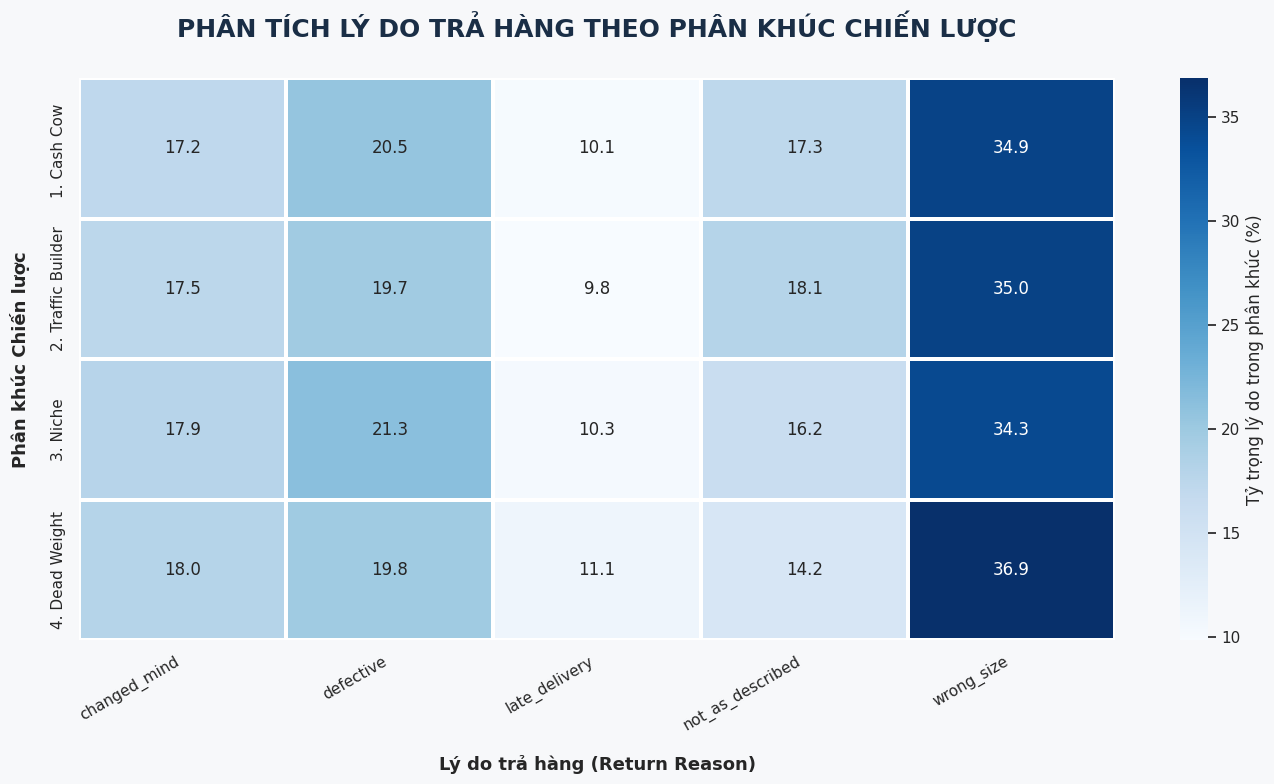


                             TỶ TRỌNG LÝ DO TRẢ HÀNG (%) THEO TỪNG NHÓM                             
return_reason      changed_mind defective late_delivery not_as_described wrong_size
strategic_segment                                                                  
1. Cash Cow               17.2%     20.5%         10.1%            17.3%      34.9%
2. Traffic Builder        17.5%     19.7%          9.8%            18.1%      35.0%
3. Niche                  17.9%     21.3%         10.3%            16.2%      34.3%
4. Dead Weight            18.0%     19.8%         11.1%            14.2%      36.9%


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. CHUẨN BỊ DỮ LIỆU (MERGE RETURNS VỚI SEGMENTS)
# =========================================================
# Giả sử trong df_returns của bạn có cột 'return_reason' hoặc 'reason'
# Nếu tên cột khác, bạn hãy điều chỉnh lại tên 'return_reason' ở dưới nhé
df_returns_detailed = pd.merge(
    df_returns, 
    df_seg[['product_id', 'strategic_segment', 'category']], 
    on='product_id', 
    how='left'
)

# Tạo bảng chéo (Crosstab) giữa Phân khúc và Lý do trả hàng
# Tính tỷ trọng % theo từng Phân khúc (hàng) để thấy phân bổ lý do
reason_matrix = pd.crosstab(
    df_returns_detailed['strategic_segment'], 
    df_returns_detailed['return_reason'] # Thay bằng tên cột lý do thực tế của bạn
)

# Sắp xếp thứ tự các nhóm chiến lược cho logic (1 -> 4)
desired_order = ['1. Cash Cow ', '2. Traffic Builder', '3. Niche', '4. Dead Weight']
existing_rows = [row for row in desired_order if row in reason_matrix.index]
reason_matrix = reason_matrix.loc[existing_rows]

# Tính % theo dòng (Trong 100 ca trả hàng của nhóm đó, lý do nào chiếm bao nhiêu %)
reason_pct = reason_matrix.div(reason_matrix.sum(axis=1), axis=0) * 100

# =========================================================
# 2. TRỰC QUAN HÓA HEATMAP (CORPORATE STYLE)
# =========================================================
plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(14, 8))
fig.set_facecolor('#F7F8FA')
ax.set_facecolor('#F7F8FA')

# Vẽ Heatmap với bảng màu Blues
sns.heatmap(
    reason_pct, 
    annot=True, 
    fmt=".1f", 
    cmap="Blues", 
    linewidths=1.5, 
    linecolor='white',
    cbar_kws={'label': 'Tỷ trọng lý do trong phân khúc (%)'},
    ax=ax
)

# Tinh chỉnh tiêu đề và nhãn theo phong cách báo cáo C-Level
plt.title('PHÂN TÍCH LÝ DO TRẢ HÀNG THEO PHÂN KHÚC CHIẾN LƯỢC', 
          fontsize=18, fontweight='black', pad=30, color='#1A2E46')
plt.ylabel('Phân khúc Chiến lược', fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel('Lý do trả hàng (Return Reason)', fontsize=13, fontweight='bold', labelpad=15)

# Định dạng nhãn trục
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

# =========================================================
# 3. IN BẢNG TÓM TẮT DƯỚI DẠNG TEXT
# =========================================================
print("\n" + "="*100)
print(f"{'TỶ TRỌNG LÝ DO TRẢ HÀNG (%) THEO TỪNG NHÓM':^100}")
print("="*100)
print(reason_pct.applymap(lambda x: f"{x:.1f}%").to_string())
print("="*100)

### **Phân tích Độ nhạy cảm Khuyến mãi (Promo Sensitivity Analysis)**

**1. Mục tiêu Phân tích**
Xác định mức độ phụ thuộc của từng danh mục sản phẩm vào các chương trình ưu đãi. Chỉ số này giúp bộ phận Marketing nhận diện được nhóm sản phẩm nào khách hàng chỉ mua khi có giảm giá (Promotion-addicted) và nhóm nào có sức mua tự nhiên tốt.

**2. Phương pháp Tính toán**
*   **Doanh thu thuần (Net Revenue):** Lợi nhuận thực thu trên mỗi dòng sản phẩm sau khi đã trừ đi các khoản giảm giá trực tiếp và tiền hoàn trả.
    *   *Công thức:* $Net\_Revenue = (Quantity \times Unit\_Price) - Discount\_Amount - Refund\_Amount$
*   **Doanh thu từ Khuyến mãi (Promo Net Revenue):** Tổng doanh thu thuần chỉ tính riêng cho những sản phẩm có áp dụng chiết khấu ($Discount\_Amount > 0$).
*   **Độ nhạy cảm Khuyến mãi (%):** Tỷ trọng doanh thu có được từ các chương trình khuyến mãi so với tổng doanh thu thuần của toàn danh mục.
    *   *Công thức:* $Promo\_Sensitivity = \frac{\sum Net\_Revenue_{Promo}}{\sum Net\_Revenue_{Total}} \times 100$
*   **Xếp hạng (Ranking):** Dữ liệu được sắp xếp theo thứ tự tăng dần của độ nhạy cảm để trực quan hóa sự chuyển biến từ nhóm "Mua hàng tự nhiên" sang nhóm "Ưa chuộng giảm giá".

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. TÍNH TOÁN DOANH THU THUẦN (NET REVENUE) THỰC TẾ
# =========================================================
# A. Tổng hợp dữ liệu hoàn trả để không bị nhân đôi dòng khi merge
returns_agg = df_returns.groupby(['order_id', 'product_id']).agg({
    'refund_amount': 'sum'
}).reset_index()

# B. Kết hợp dữ liệu (Items + Category + Returns)
df_promo_analysis = pd.merge(
    df_order_items, 
    df_products[['product_id', 'category']], 
    on='product_id', 
    how='left'
)
df_promo_analysis = pd.merge(
    df_promo_analysis, 
    returns_agg, 
    on=['order_id', 'product_id'], 
    how='left'
).fillna(0)

# C. Công thức Net Revenue chuẩn (đã thống nhất)
df_promo_analysis['Net_Revenue'] = (
    (df_promo_analysis['quantity'] * df_promo_analysis['unit_price']) - 
    df_promo_analysis['discount_amount'] - 
    df_promo_analysis['refund_amount']
)

# D. Đánh dấu dòng sản phẩm có áp dụng Promo (discount > 0)
df_promo_analysis['is_promo'] = df_promo_analysis['discount_amount'] > 0

# =========================================================
# 2. TÍNH ĐỘ NHẠY CẢM KHUYẾN MÃI (PROMO SENSITIVITY)
# =========================================================
category_stats = df_promo_analysis.groupby('category').agg(
    total_net_rev=('Net_Revenue', 'sum'),
    # Tính tổng doanh thu chỉ từ những dòng có khuyến mãi
    promo_net_rev=('Net_Revenue', lambda x: x[df_promo_analysis.loc[x.index, 'is_promo']].sum())
).reset_index()

# Tính tỷ lệ % và sắp xếp tăng dần để vẽ thanh ngang
category_stats['promo_sensitivity'] = (category_stats['promo_net_rev'] / category_stats['total_net_rev']) * 100
category_stats = category_stats.sort_values('promo_sensitivity', ascending=True)

# =========================================================
# 3. TRỰC QUAN HÓA BẰNG PLOTLY (CORPORATE STYLE)
# =========================================================
vietnamese_font = "Arial, Helvetica, sans-serif"

fig = go.Figure()

fig.add_trace(go.Bar(
    y=category_stats['category'],
    x=category_stats['promo_sensitivity'],
    orientation='h',
    marker=dict(
        color='#4C72B0', # Màu Xanh dương Corporate trung tính
        line=dict(color='#2C3E50', width=0.8)
    ),
    # Đưa số vào giữa thanh, format 1 chữ số thập phân
    text=[f"<b>{v:.1f}%</b>" for v in category_stats['promo_sensitivity']],
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(family=vietnamese_font, size=14, color='white'),
    hovertemplate="<b>%{y}</b><br>Tỷ lệ doanh thu từ Promo: %{x:.2f}%<extra></extra>"
))

# Tinh chỉnh Layout C-Level
fig.update_layout(
    title={
        'text': "<b>ĐỘ NHẠY CẢM VỚI KHUYẾN MÃI THỰC TẾ THEO DANH MỤC</b><br>" +
                "<span style='font-size:14px; color:gray'>Dựa trên tỷ trọng Doanh thu thuần (Net Revenue) từ các sản phẩm có chiết khấu</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'family': vietnamese_font, 'size': 20, 'color': '#1A2E46'}
    },
    plot_bgcolor='#F7F8FA', # Nền xám ngà Corporate
    paper_bgcolor='#F7F8FA',
    font=dict(family=vietnamese_font, color='#2C3E50'),
    xaxis=dict(
        title="<b>Tỷ lệ doanh thu từ Promo (%)</b>",
        ticksuffix="%",
        range=[0, category_stats['promo_sensitivity'].max() * 1.15], # Nới biên để số không bị sát lề
        showgrid=True,
        gridcolor='#E5E8E8'
    ),
    yaxis=dict(title=""),
    margin=dict(t=100, b=80, l=150, r=60),
    width=1000,
    height=600
)

fig.show()